# HW02-2：房地产公司财务特征分析

- 姓名：邰尚
- 学号：23341044
- 数据来源、获取日期与样本期间：CSMAR 数据库；使用上市公司基本信息表、股权性质表、年度合并资产负债表和年度合并利润表；获取日期为 2026-09-25；样本期间为 2005—2015 年，另使用 2004 年末资产和权益计算 2005 年 ROA、ROE 的平均分母。
- AI 使用声明：使用了 Codex 辅助理解作业要求、核对数据处理口径、整理 Stata 代码和撰写报告初稿；数据下载、代码运行和结果核验由本人完成并确认。

本报告以 2005—2015 年房地产 A 股上市公司为样本，构建公司—年度非平衡面板，分析房地产上市公司数量、产权结构和财务特征的变化。总体思路是：先按年度行业和上市状态确定房地产上市公司样本，再合并产权性质、资产负债表和利润表，计算资产负债率、银行贷款占比、短期负债占比、ROA、ROE 和现金持有比率。随后分别考察全部企业的均值与中位数变化，以及国有和民营企业的描述性差异。报告只做描述性分析，不把国有与民营差异解释为产权的因果作用。

## 1. 数据、样本与变量口径

### Step 1：Markdown 分析说明

本环节说明数据来源、样本构建和变量口径。作业要求不能用当前行业或当前产权倒推历史年份，因此本文按每年年末的行业名称和产权性质构建公司—年度样本。财务指标使用年度合并报表，ROA 和 ROE 使用上年末与本年末的平均资产、平均权益作为分母。

分析要点：

- 样本为 2005—2015 年房地产 A 股上市公司年度非平衡面板。
- 房地产行业依据年度 `industry_name` 识别，包含“房地产开发与经营业”“房地产业”“房地产经纪业”“房地产管理业”。
- 产权分为国有、民营、其他；其他包含外资、混合性质、其他和产权不明。
- 对平均权益非正的 ROE 置为缺失，避免异常分母扭曲比率解释。
- 对极端值不直接删除，先保留并单独检查。

In [ ]:
clear all
set more off

local data "data"
local out  "results"

capture mkdir "`out'"

use "`data'/合并后数据.dta", clear

format year %9.0f
isid stkcd year

graph set window fontface "Songti SC"

In [ ]:
duplicates report stkcd year

tab year
tab owner_type, missing
tab listing_state, missing

misstable summarize lev bankloan shortdebt roa roe cash_ta

foreach v in lev bankloan shortdebt roa roe cash_ta {
    summarize `v', detail
}

### Step 2：代码与实际输出

样本处理表如下：

| 处理阶段 | 公司—年度观测数 | 公司数 | 年份范围 |
| --- | --- | --- | --- |
| 最终房地产公司—年度样本 | 989 | 140 | 2005-2015 |

年度公司数量如下：

| 年份 | 公司数 |
| --- | --- |
| 2005 | 55 |
| 2006 | 58 |
| 2007 | 65 |
| 2008 | 73 |
| 2009 | 81 |
| 2010 | 102 |
| 2011 | 105 |
| 2012 | 119 |
| 2013 | 113 |
| 2014 | 109 |
| 2015 | 109 |

### Step 3：结果解读

清洗后样本共有 989 个公司—年度观测，覆盖 140 家房地产上市公司。`stkcd year` 主键唯一，说明每个公司每年只有一条记录。样本是非平衡面板，年度公司数从 2005 年的 55 家上升到 2012 年的 119 家，随后回落并在 2015 年保持 109 家。公司数量变化可能来自上市、退市、行业分类变化和样本进出，不能简单理解为房地产行业真实企业数量的增减。

财务指标方面，`bankloan` 缺失 1 个观测，ROA 缺失 9 个观测，ROE 缺失 24 个观测。缺失主要来自长期借款缺失、上年资产/权益缺失或平均权益非正。本文没有把这些缺失填零，而是保留为缺失并在有效样本量表中报告。

## 2. 公司数量与产权结构

### Step 1：Markdown 分析说明

本环节统计房地产上市公司年度数量和产权结构。产权结构分为国有、民营和其他，其中“其他”不是民营，也不和国有合并。年度公司数不因财务指标缺失而删除，因为数量统计反映的是样本构成，而不是财务指标可用性。

分析要点：

- 逐年统计房地产上市公司总数。
- 分别统计国有、民营和其他公司数量。
- 计算国有和民营在当年房地产样本中的占比。
- 解释产权结构变化时，只做描述性说明。

In [ ]:
* 年度公司数
preserve
    gen one = 1
    collapse (sum) firm_n = one, by(year)
    export delimited using "`out'/样本年度公司数.csv", replace

    twoway line firm_n year, ///
        title("房地产A股上市公司数量") ///
        xtitle("年份") ytitle("公司数量") ///
        xlabel(2005(1)2015, angle(45)) ///
        ylabel(, angle(0))
    graph export "`out'/房地产上市公司数量.png", replace width(1800)
restore

* 样本处理表
preserve
    gen stage = "最终房地产公司-年度样本"
    gen one = 1
    egen firm_tag = tag(stkcd)
    collapse (sum) firm_year = one (sum) firm_n = firm_tag, by(stage)
    export delimited using "`out'/样本处理表.csv", replace
restore

In [ ]:
* 产权结构数量
preserve
    gen one = 1
    collapse (sum) firm_n = one, by(year owner_type)
    export delimited using "`out'/产权结构数量表.csv", replace

    twoway ///
        (line firm_n year if owner_type == "国有", lcolor(navy)) ///
        (line firm_n year if owner_type == "民营", lcolor(maroon)) ///
        (line firm_n year if owner_type == "其他", lcolor(forest_green)), ///
        title("房地产上市公司产权结构数量") ///
        xtitle("年份") ytitle("公司数量") ///
        xlabel(2005(1)2015, angle(45)) ///
        ylabel(, angle(0)) ///
        legend(order(1 "国有" 2 "民营" 3 "其他"))
    graph export "`out'/产权结构数量.png", replace width(1800)
restore

* 国有与民营占比
preserve
    gen one = 1
    collapse (sum) firm_n = one, by(year owner_type)
    bysort year: egen total_n = total(firm_n)
    gen share = firm_n / total_n
    keep if inlist(owner_type, "国有", "民营")
    export delimited using "`out'/国有民营占比表.csv", replace

    twoway ///
        (line share year if owner_type == "国有", lcolor(navy)) ///
        (line share year if owner_type == "民营", lcolor(maroon)), ///
        title("国有与民营房地产上市公司占比") ///
        xtitle("年份") ytitle("占比") ///
        xlabel(2005(1)2015, angle(45)) ///
        ylabel(0(0.1)1, angle(0) format(%3.1f)) ///
        legend(order(1 "国有" 2 "民营"))
    graph export "`out'/国有民营占比.png", replace width(1800)
restore

### 房地产 A 股上市公司数量

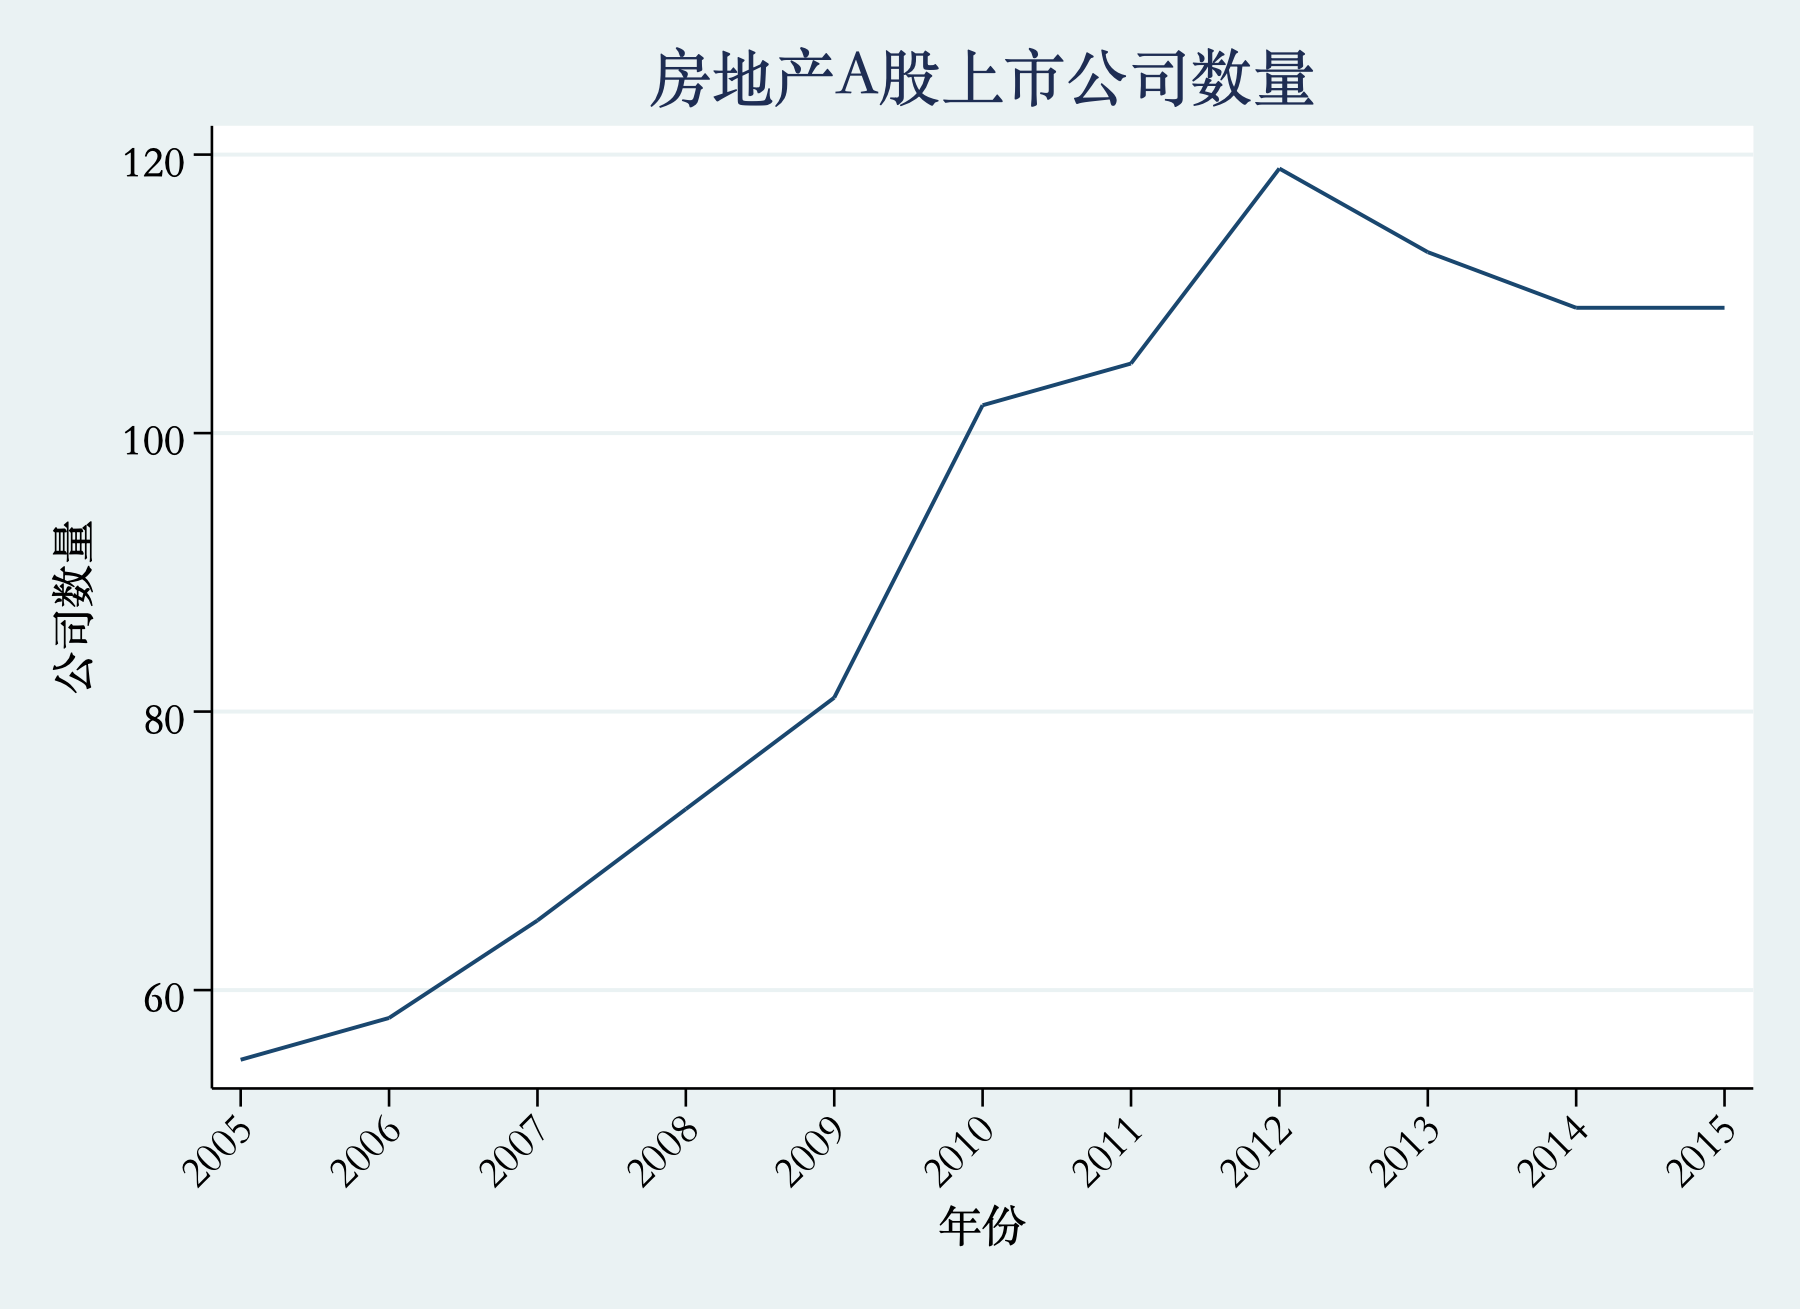

### 房地产上市公司产权结构数量

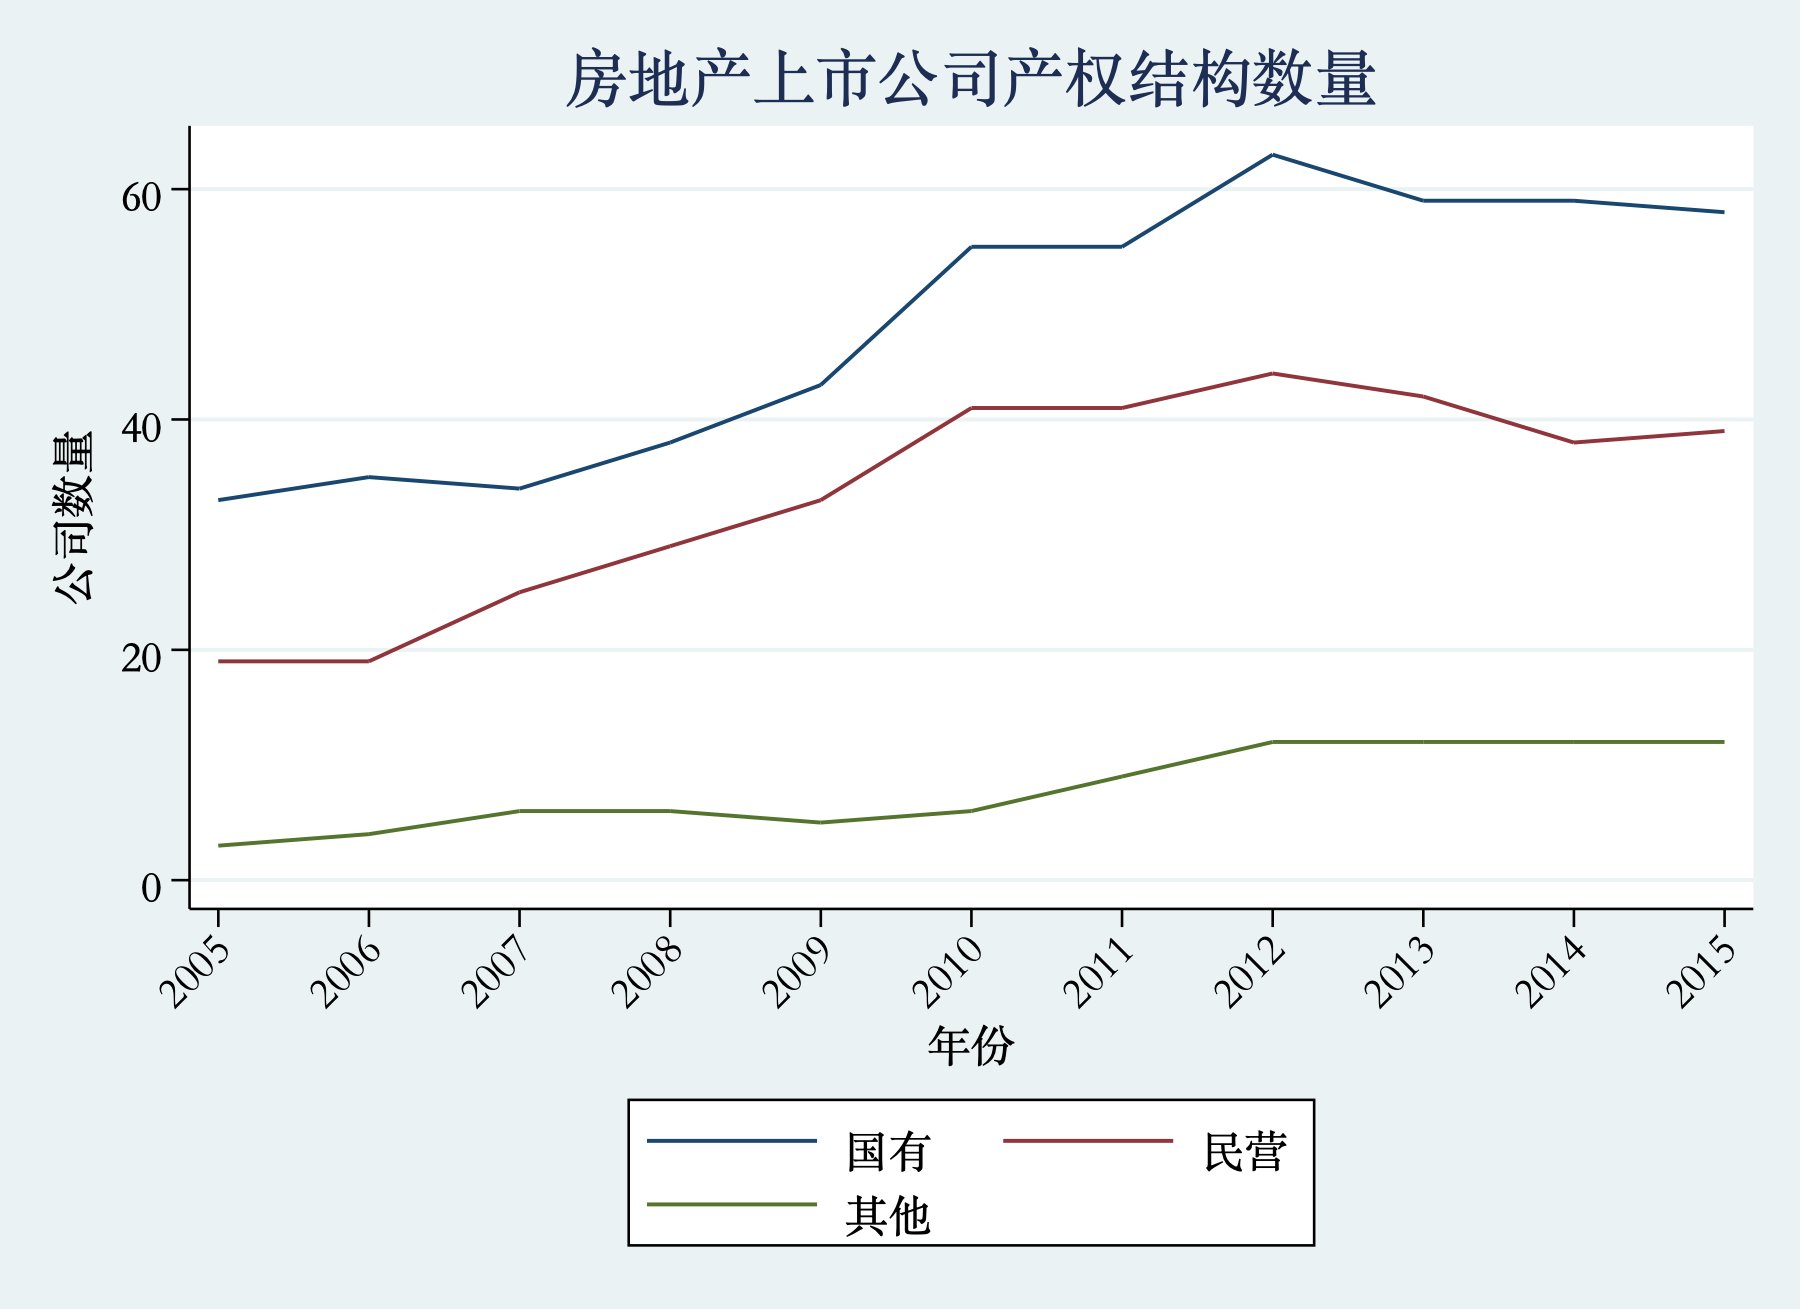

### 国有与民营房地产上市公司占比

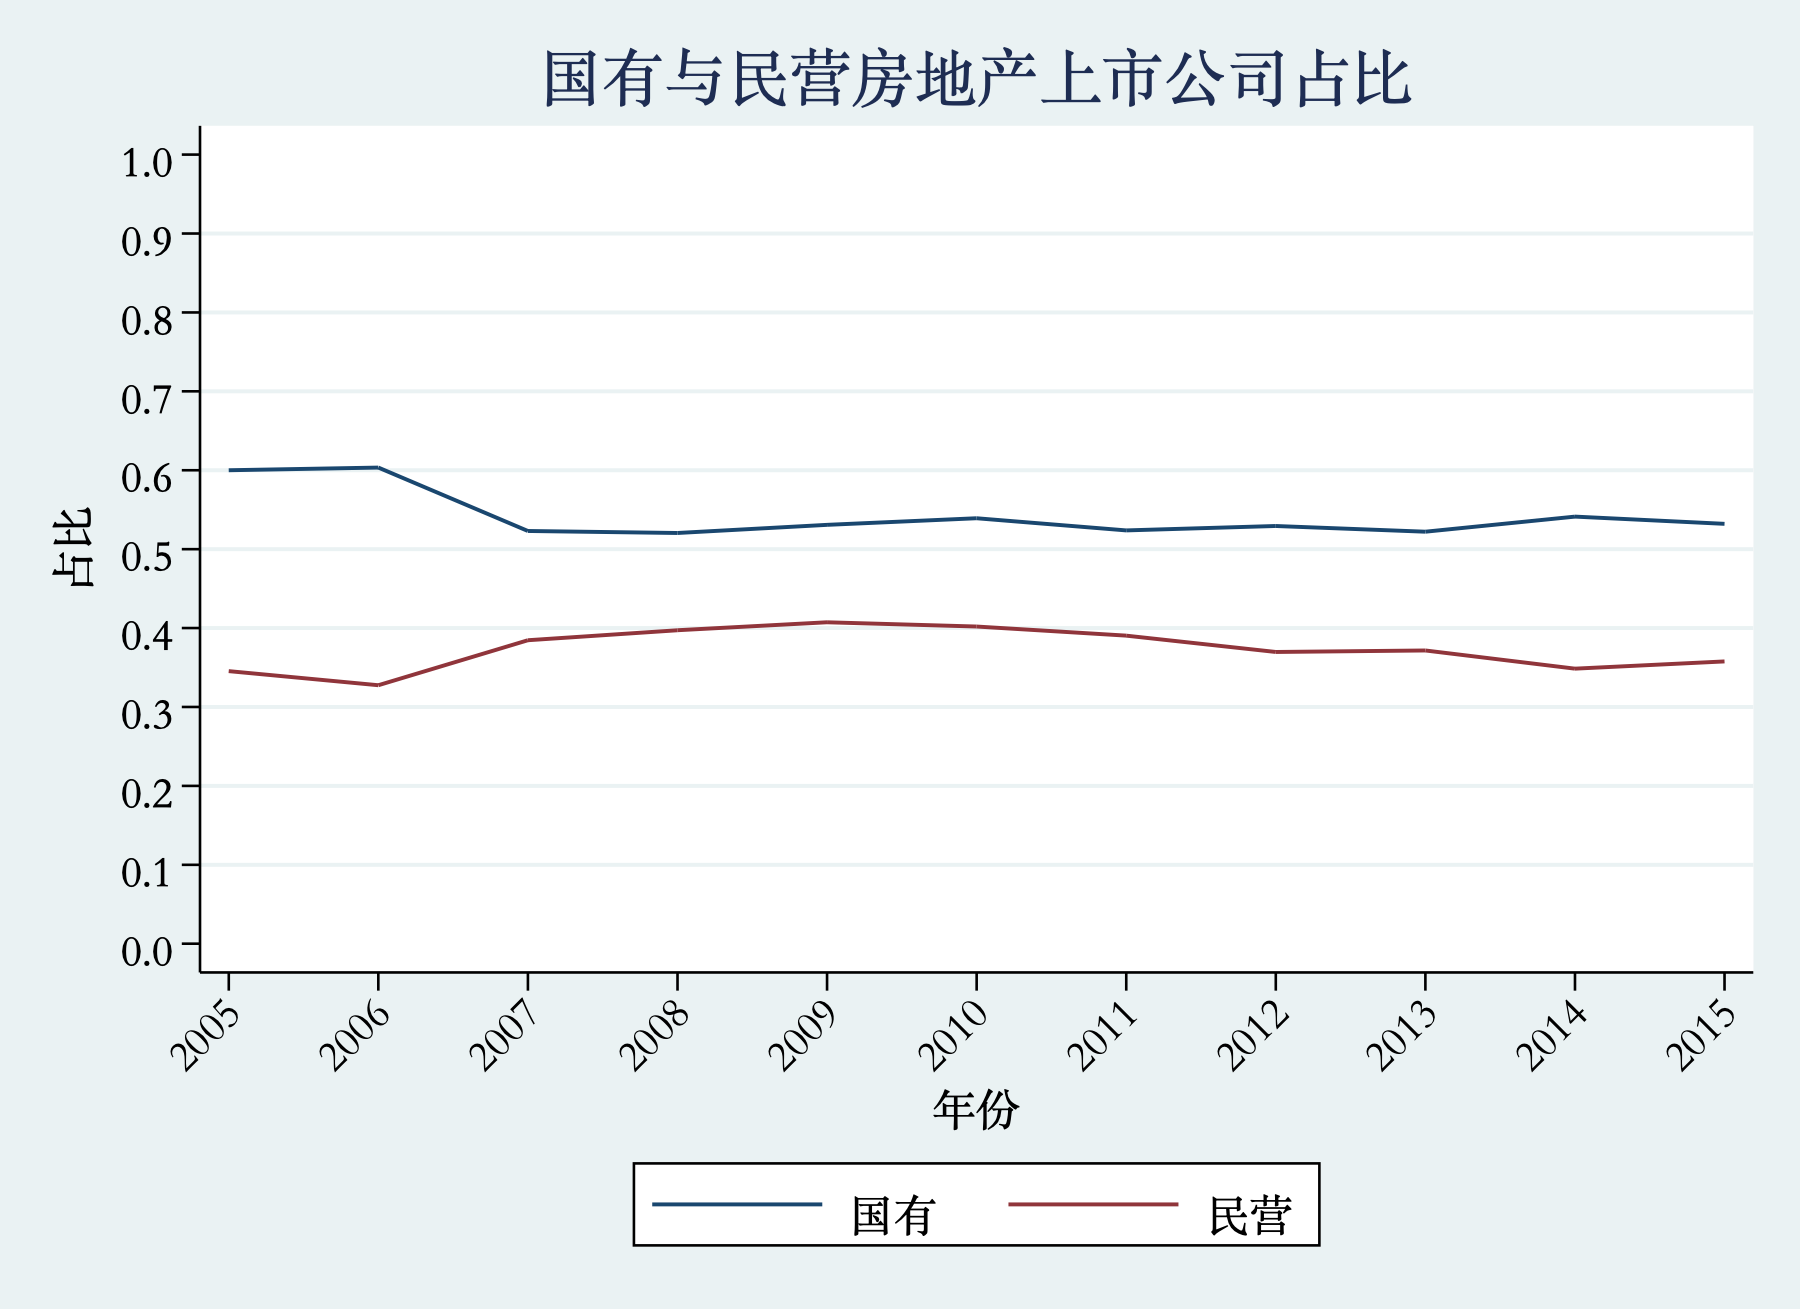

产权结构年度统计如下：

| 年份 | 国有 | 民营 | 其他 | 总数 | 国有占比（%） | 民营占比（%） |
| --- | --- | --- | --- | --- | --- | --- |
| 2005.000 | 33.000 | 19.000 | 3.000 | 55.000 | 60.000 | 34.500 |
| 2006.000 | 35.000 | 19.000 | 4.000 | 58.000 | 60.300 | 32.800 |
| 2007.000 | 34.000 | 25.000 | 6.000 | 65.000 | 52.300 | 38.500 |
| 2008.000 | 38.000 | 29.000 | 6.000 | 73.000 | 52.100 | 39.700 |
| 2009.000 | 43.000 | 33.000 | 5.000 | 81.000 | 53.100 | 40.700 |
| 2010.000 | 55.000 | 41.000 | 6.000 | 102.000 | 53.900 | 40.200 |
| 2011.000 | 55.000 | 41.000 | 9.000 | 105.000 | 52.400 | 39.000 |
| 2012.000 | 63.000 | 44.000 | 12.000 | 119.000 | 52.900 | 37.000 |
| 2013.000 | 59.000 | 42.000 | 12.000 | 113.000 | 52.200 | 37.200 |
| 2014.000 | 59.000 | 38.000 | 12.000 | 109.000 | 54.100 | 34.900 |
| 2015.000 | 58.000 | 39.000 | 12.000 | 109.000 | 53.200 | 35.800 |

### Step 3：结果解读

房地产上市公司数量在 2005—2012 年总体上升，从 55 家增加到 119 家，2013 年以后回落到 109 家。样本进出检查显示，2010 年新增 22 家、退出 1 家，2012 年新增 22 家、退出 8 家；2013 年和 2014 年则出现净退出。这说明数量变化既包含新上市和行业进入，也包含行业分类变化、暂停上市或退出样本。

产权结构上，国有企业始终占比较高。国有占比从 2005 年的 60.0% 下降到 2007—2009 年约 52%—53%，2015 年为 53.2%。民营占比从 2005 年的 34.5% 上升到 2009—2010 年约 40%，2015 年为 35.8%。其他类别在样本后期稳定在 12 家左右，占比约一成。由于“其他”包括外资、混合性质和产权不明，国有与民营占比之和小于 100% 是合理的。

核心发现：

- 样本公司数先升后降，峰值出现在 2012 年。
- 国有企业数量和占比长期高于民营企业。
- 民营企业占比在 2008—2011 年较高，之后略有下降。
- 数量和产权结构变化可能受样本进出与行业分类变化影响，不能直接解释为市场结构的因果变化。

## 3. 全部房地产企业财务指标时序

### Step 1：Markdown 分析说明

本环节对六个财务指标分别计算年度均值和中位数。均值容易受到极端值影响，中位数更能反映典型公司。因此，若均值与中位数差异较大，需要结合异常值、负权益、ST 公司和样本进出来解释。

六个指标口径：

- 资产负债率 = 总负债 / 总资产。
- 银行贷款占比 = (短期借款 + 长期借款) / 总负债。
- 短期负债占比 = 流动负债 / 总负债。
- ROA = 合并净利润 / 平均总资产。
- ROE = 合并净利润 / 平均所有者权益。
- 现金持有比率 = 货币资金 / 总资产。

In [ ]:
local vars lev bankloan shortdebt roa roe cash_ta

foreach v of local vars {

    local cname "`v'"
    if "`v'" == "lev"       local cname "资产负债率"
    if "`v'" == "bankloan"  local cname "银行贷款占比"
    if "`v'" == "shortdebt" local cname "短期负债占比"
    if "`v'" == "roa"       local cname "ROA"
    if "`v'" == "roe"       local cname "ROE"
    if "`v'" == "cash_ta"   local cname "现金持有比率"

    preserve
        collapse (count) N = `v' (mean) mean = `v' (median) median = `v', by(year)
        export delimited using "`out'/`v'_全部企业年度统计.csv", replace

        twoway ///
            (line mean year, lcolor(navy)) ///
            (line median year, lcolor(maroon)), ///
            title("`cname'：全部房地产企业均值与中位数") ///
            xtitle("年份") ytitle("指标值") ///
            xlabel(2005(1)2015, angle(45)) ///
            ylabel(, angle(0)) ///
            legend(order(1 "均值" 2 "中位数"))
        graph export "`out'/`v'_全部企业均值中位数.png", replace width(1800)
    restore
}

### 资产负债率：全部企业均值与中位数

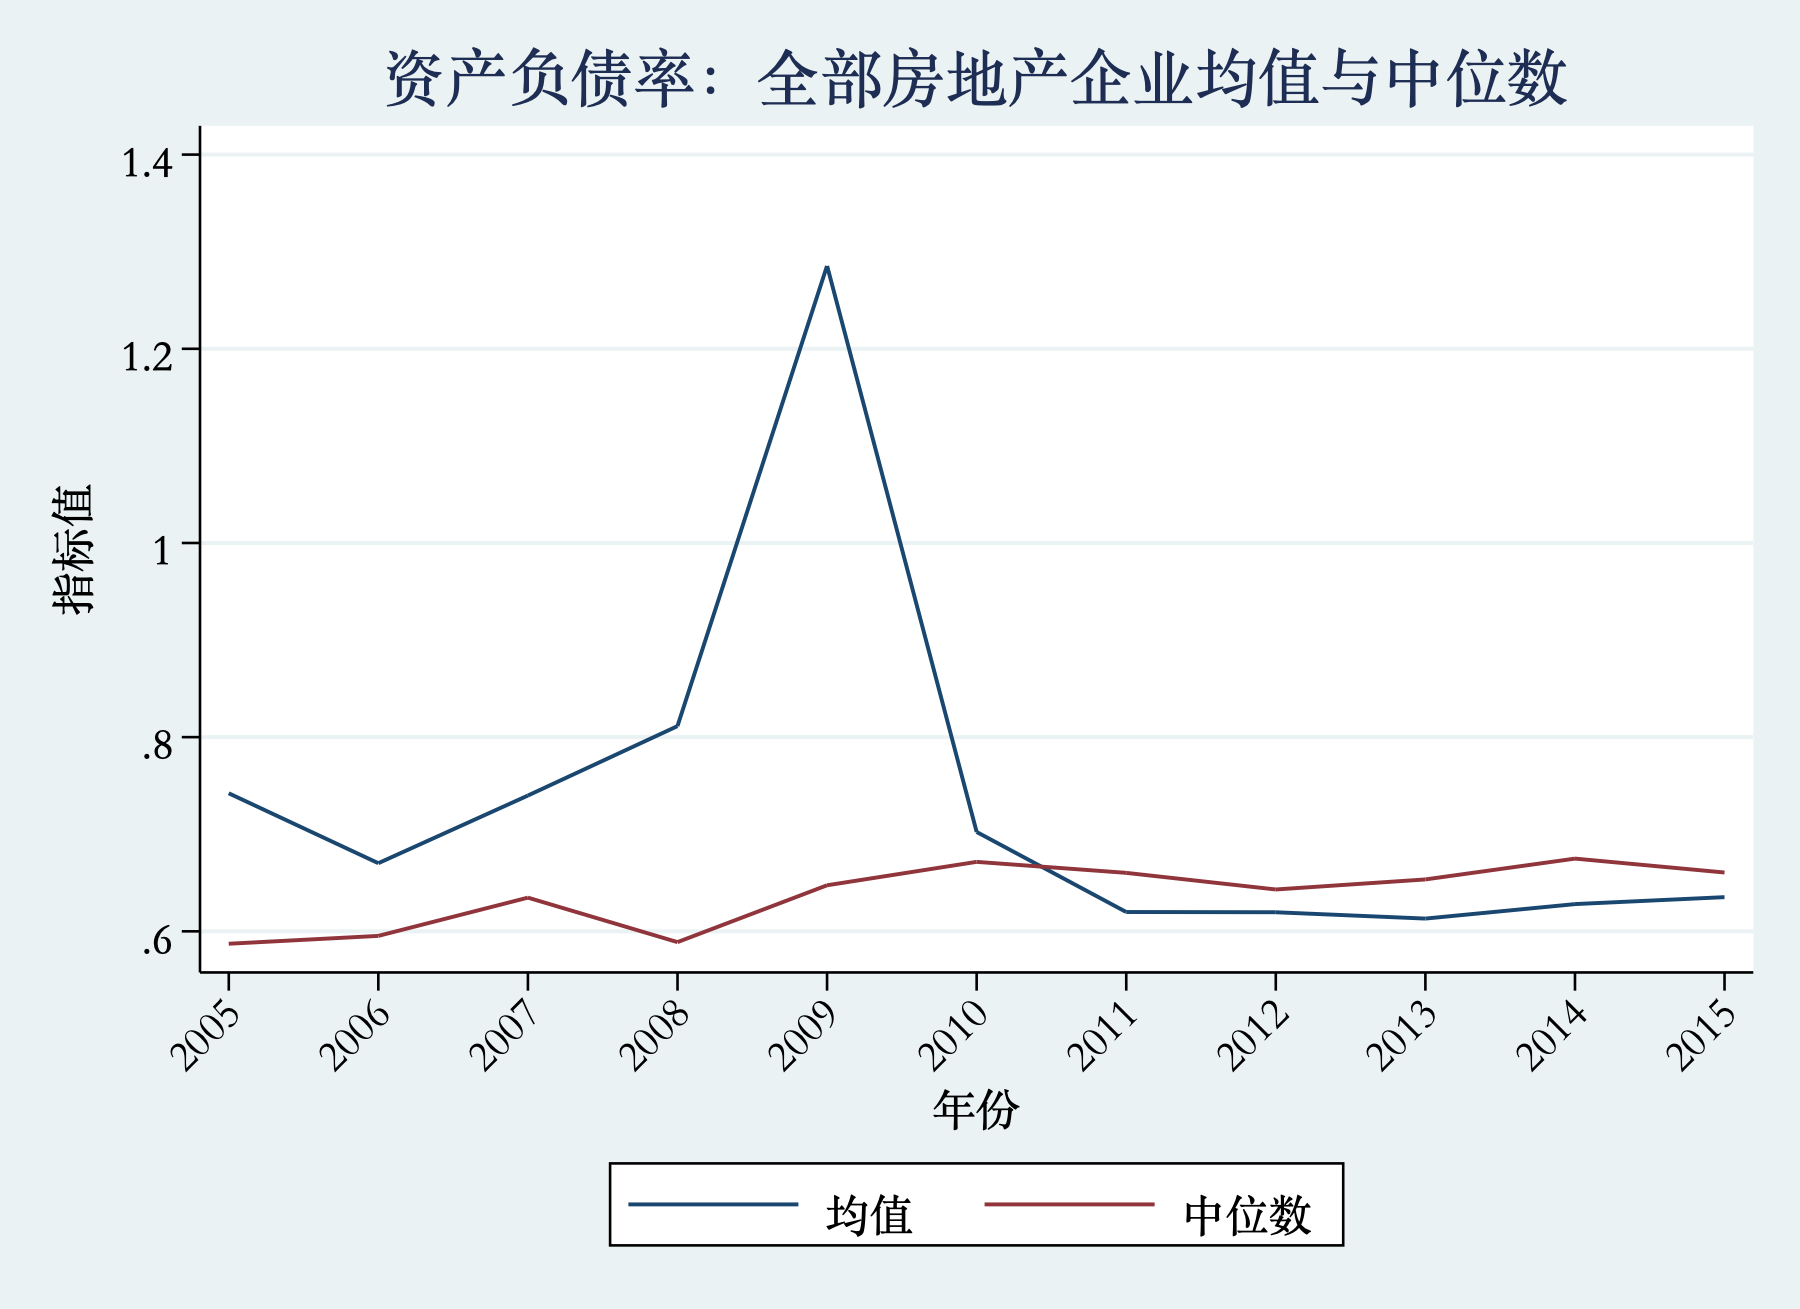

### 银行贷款占比：全部企业均值与中位数

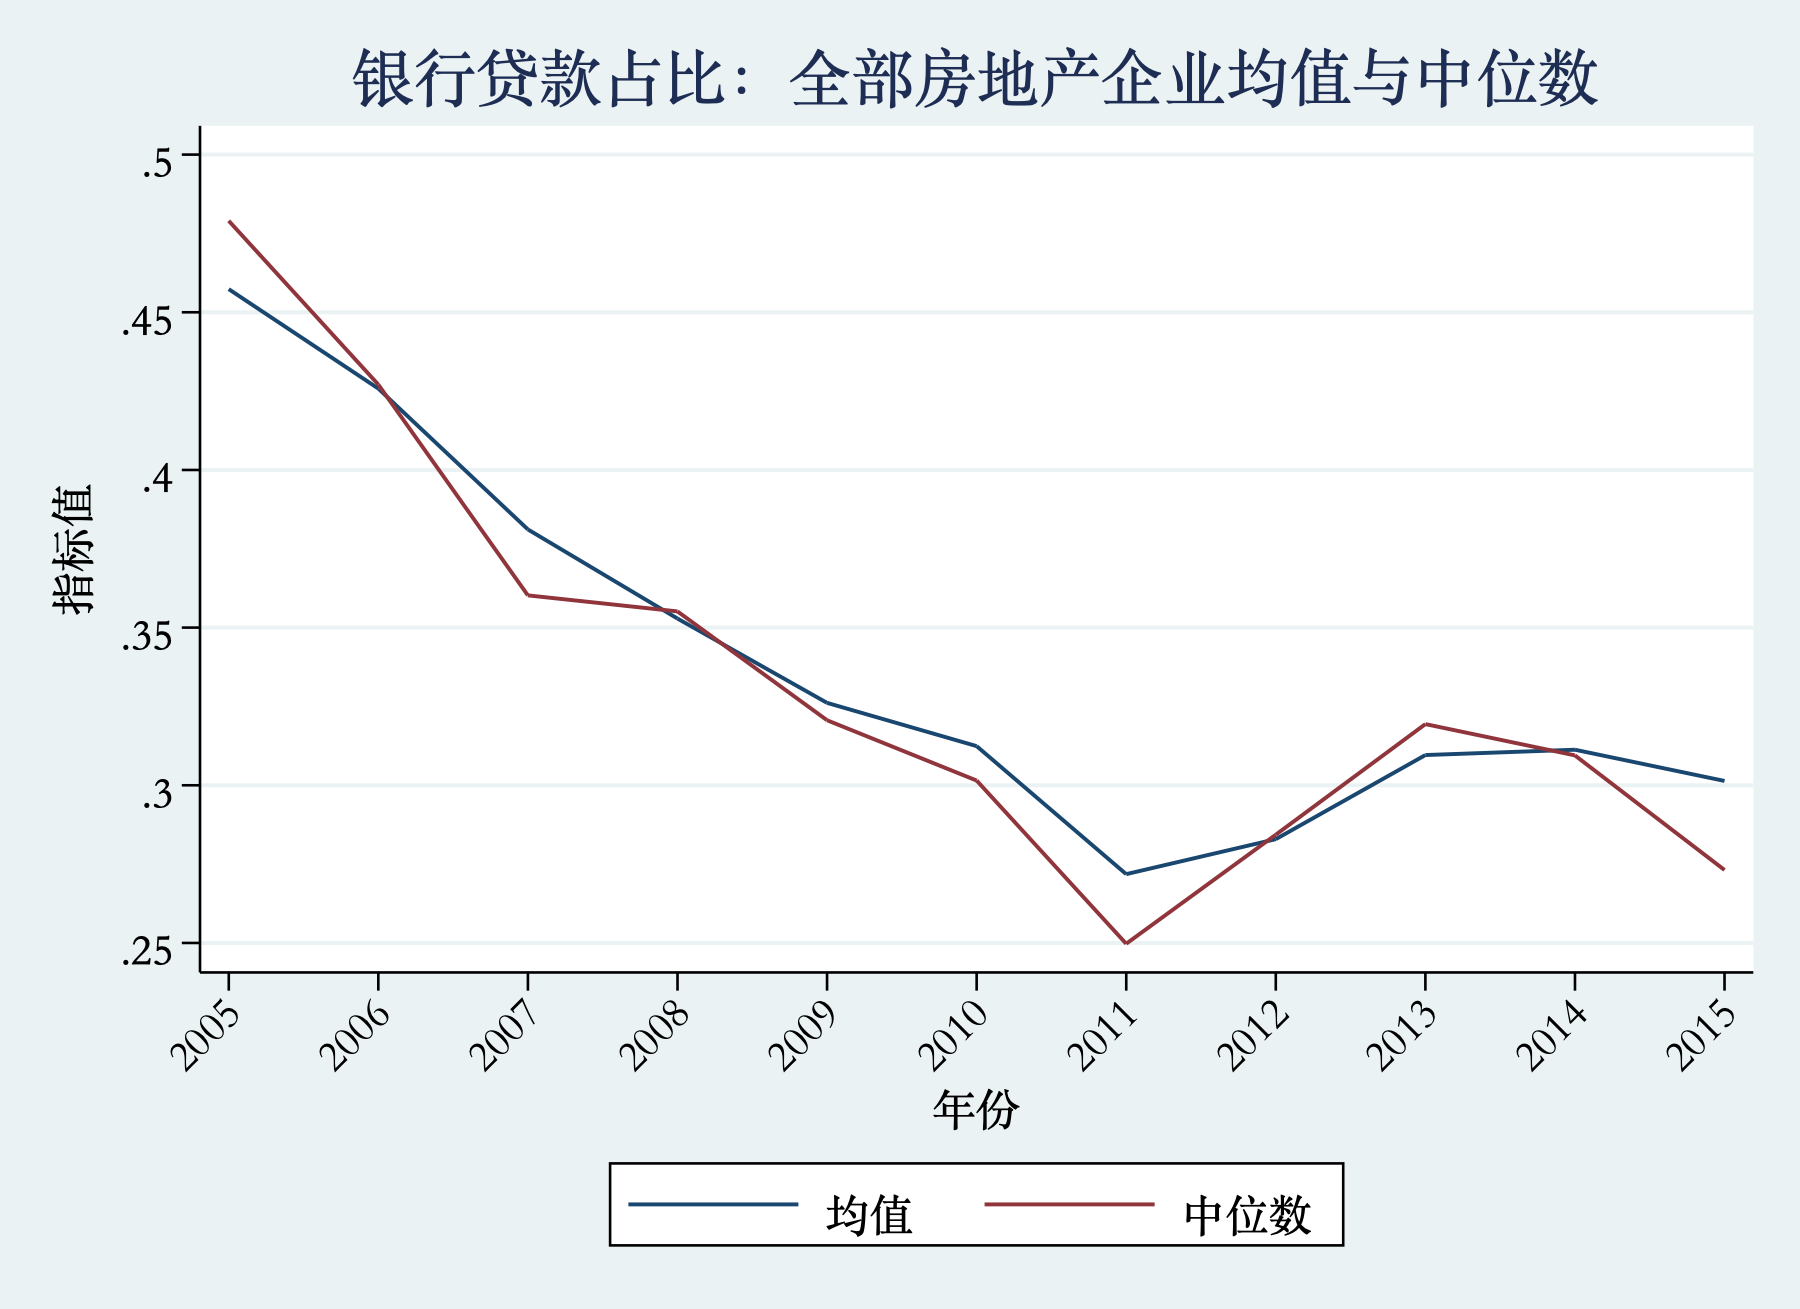

### 短期负债占比：全部企业均值与中位数

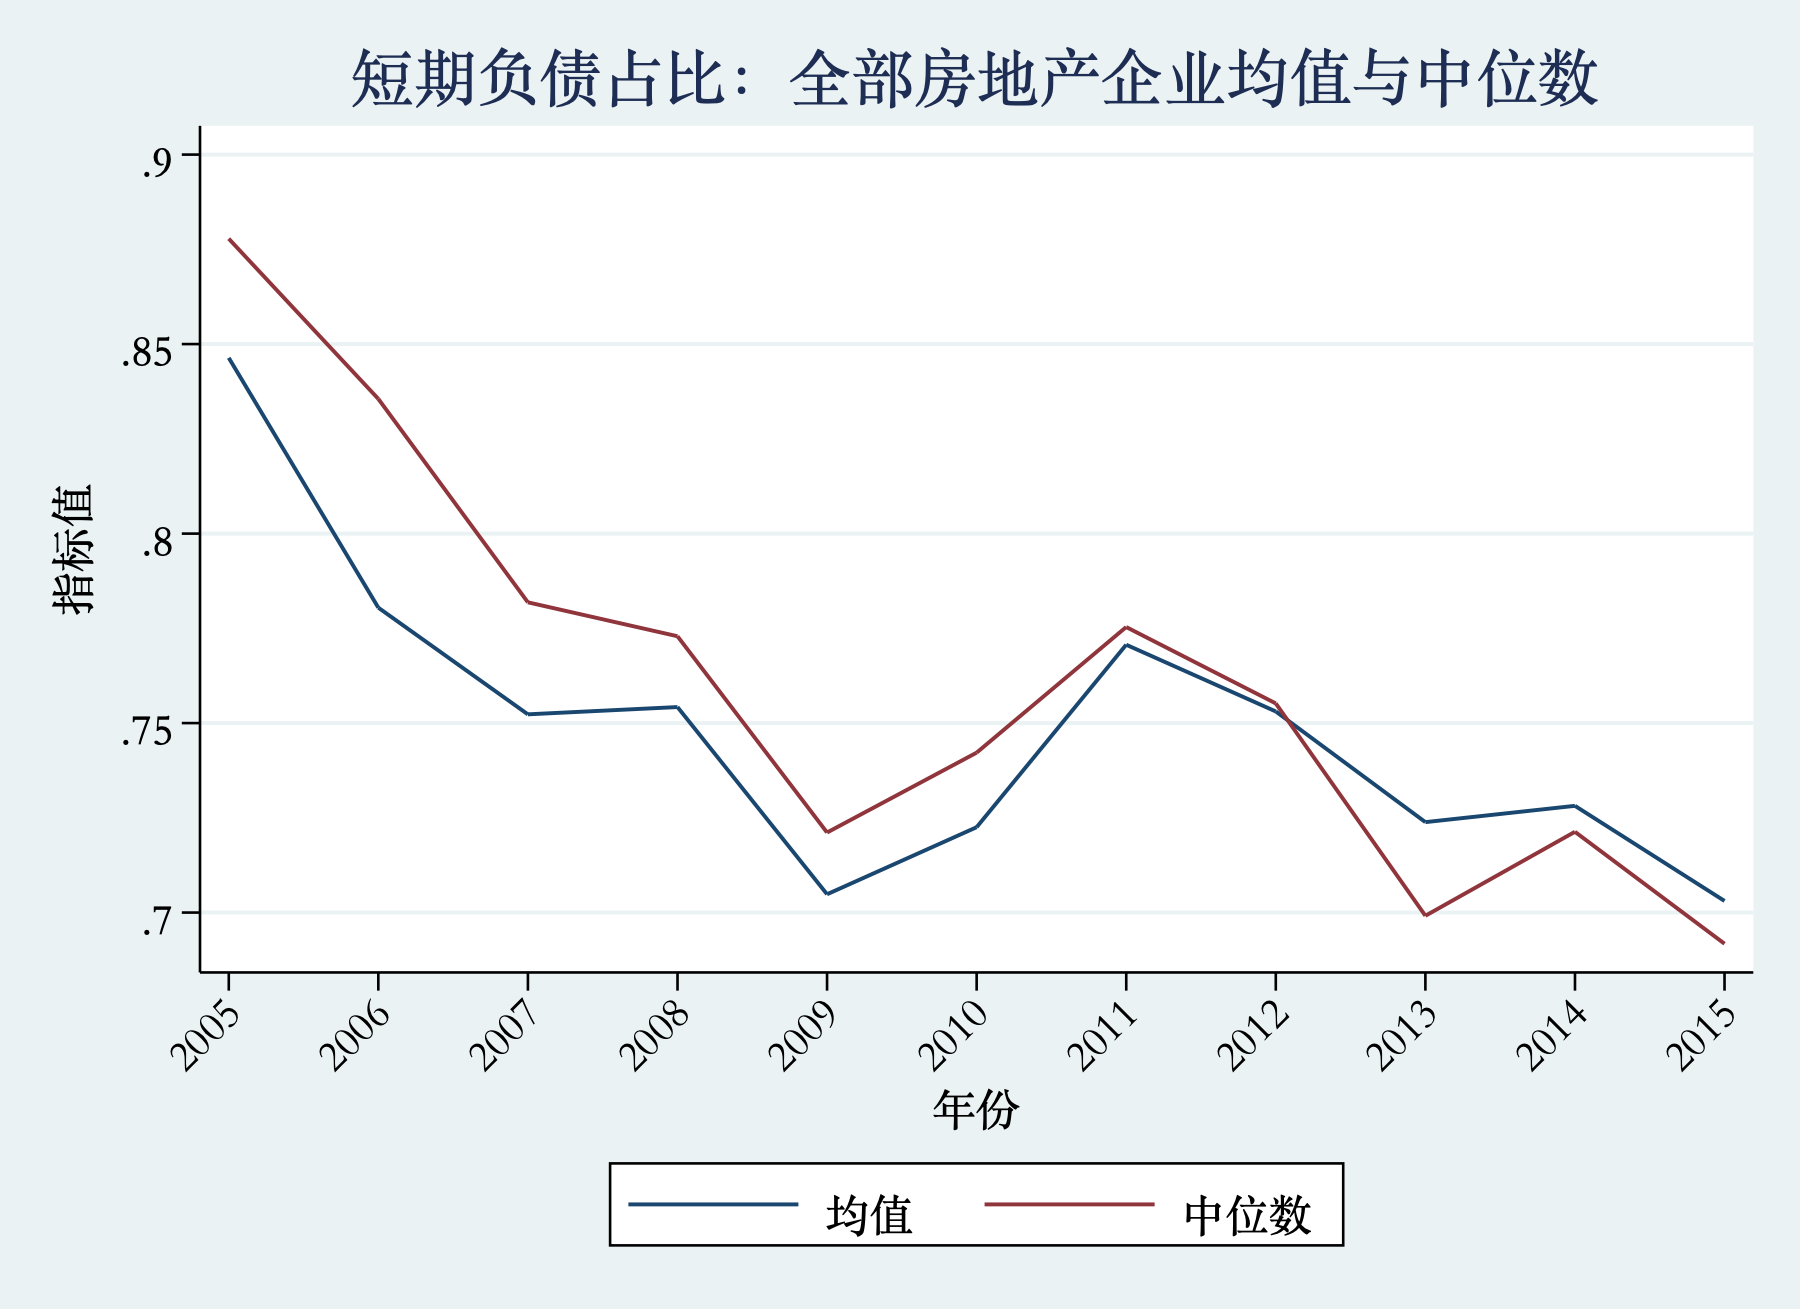

### ROA：全部企业均值与中位数

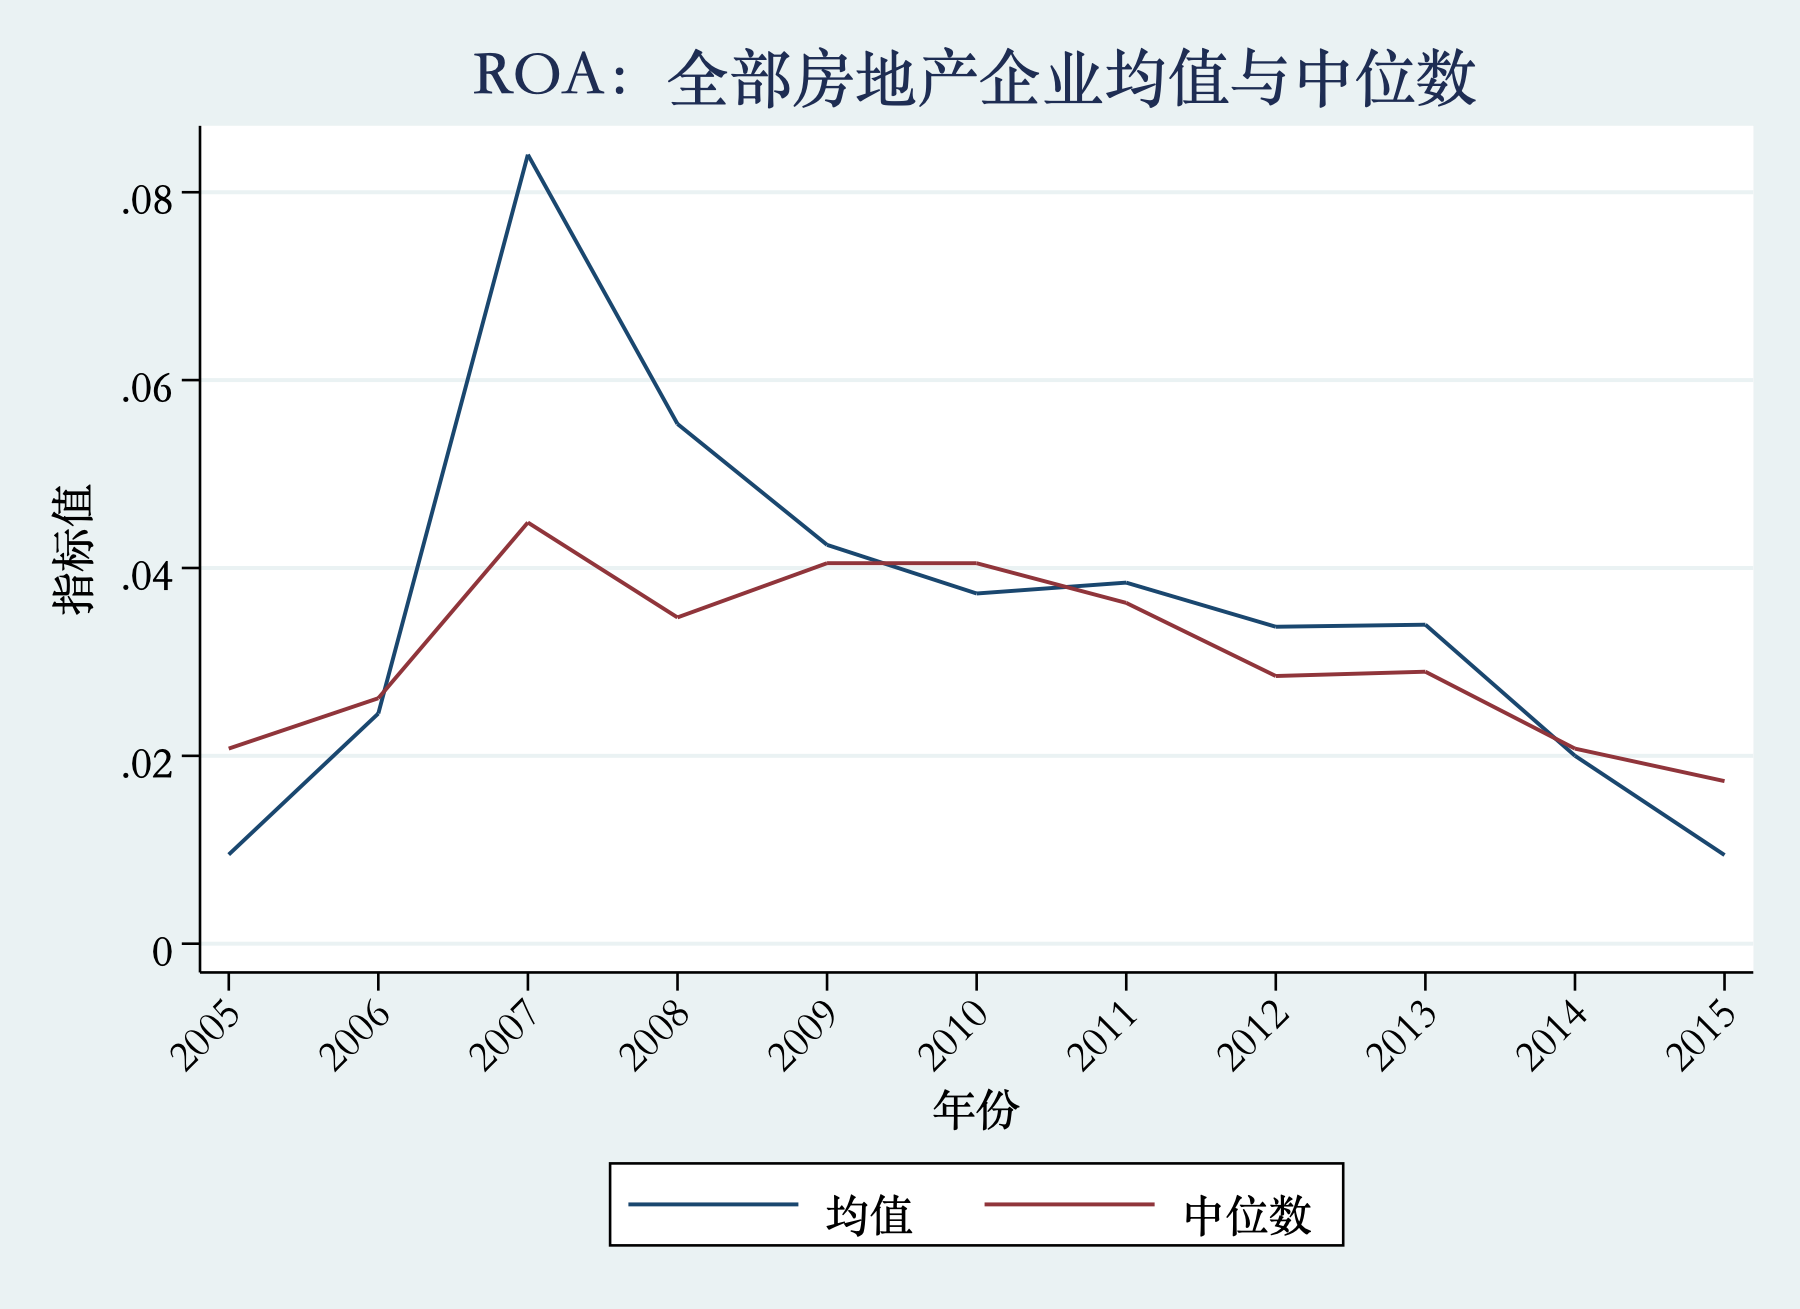

### ROE：全部企业均值与中位数

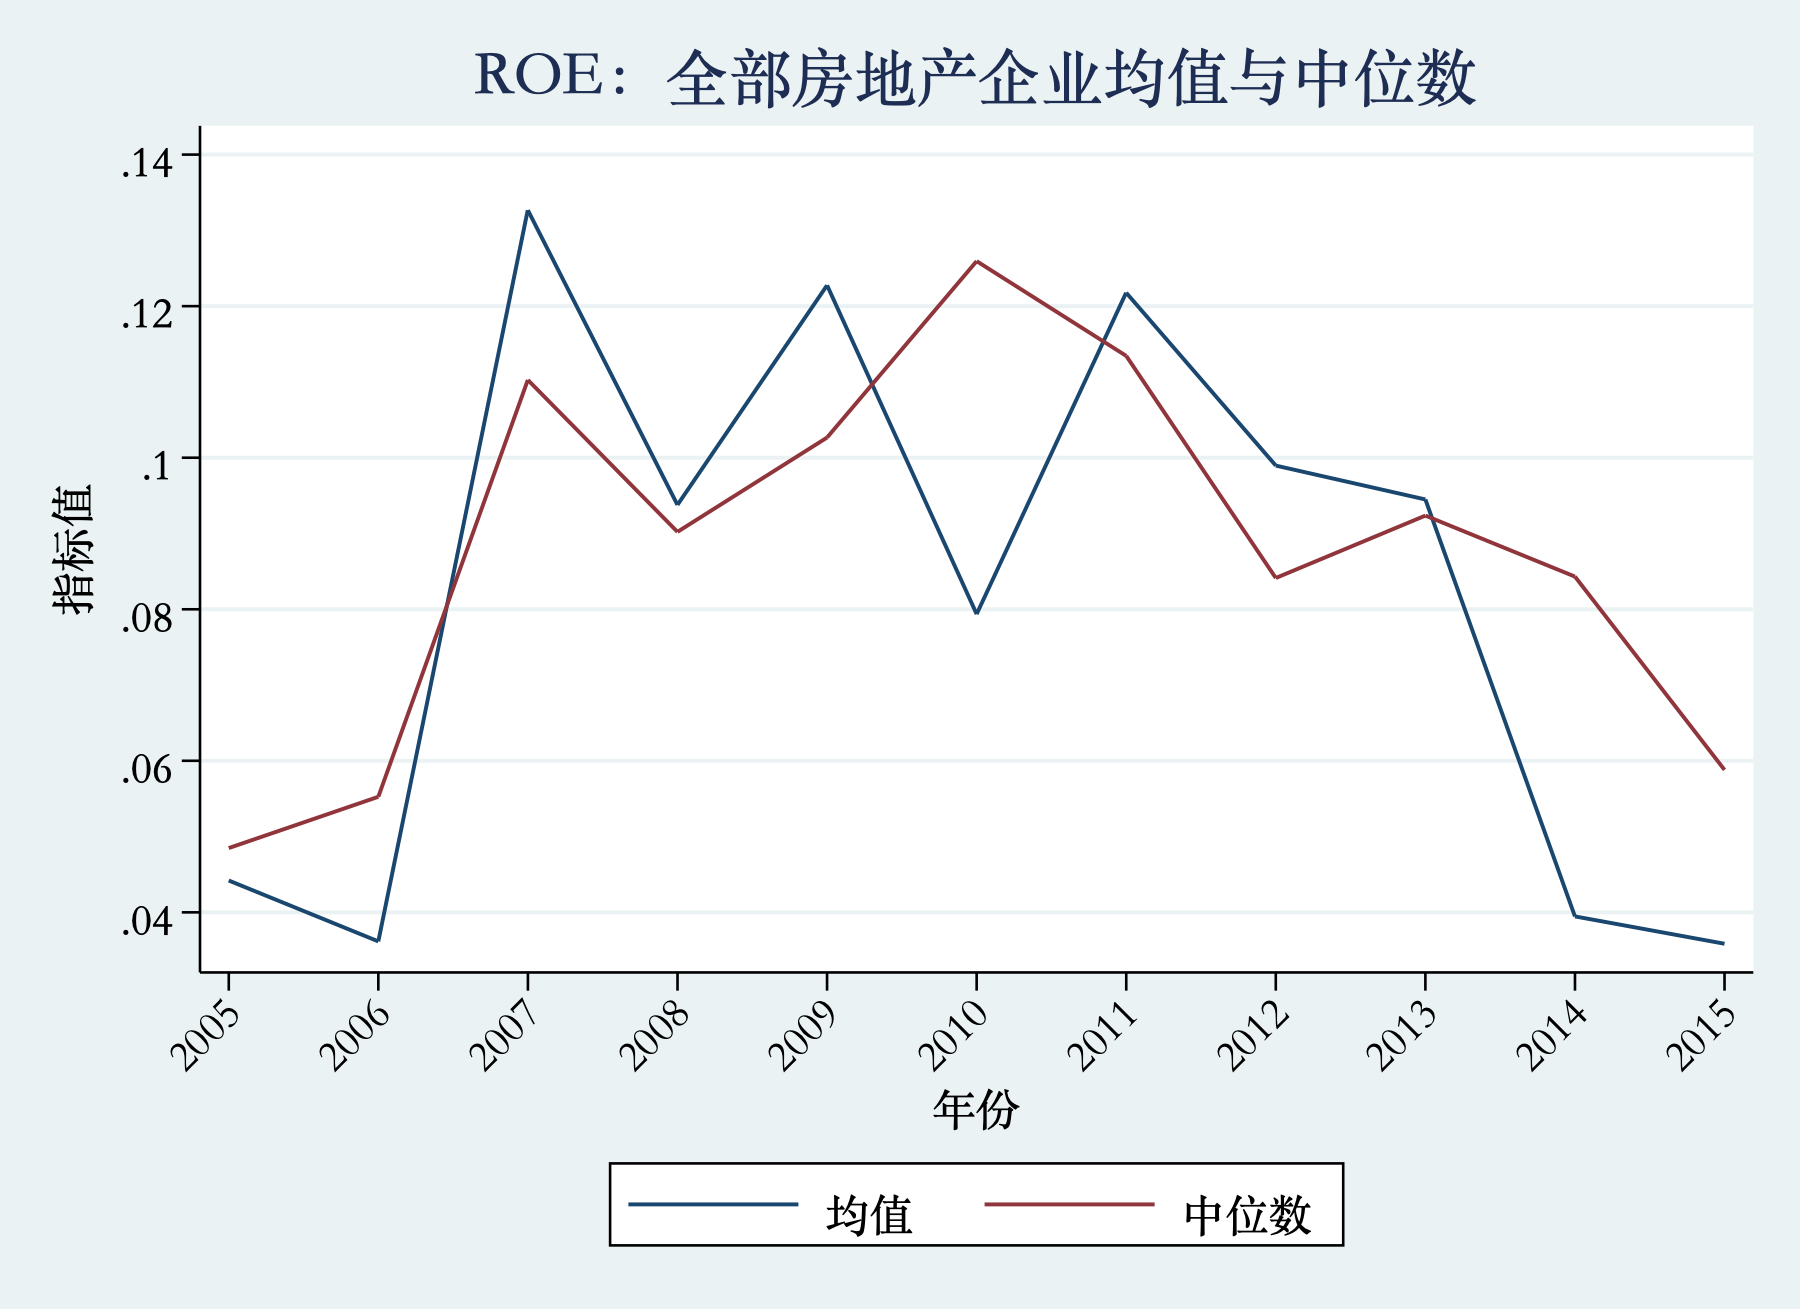

### 现金持有比率：全部企业均值与中位数

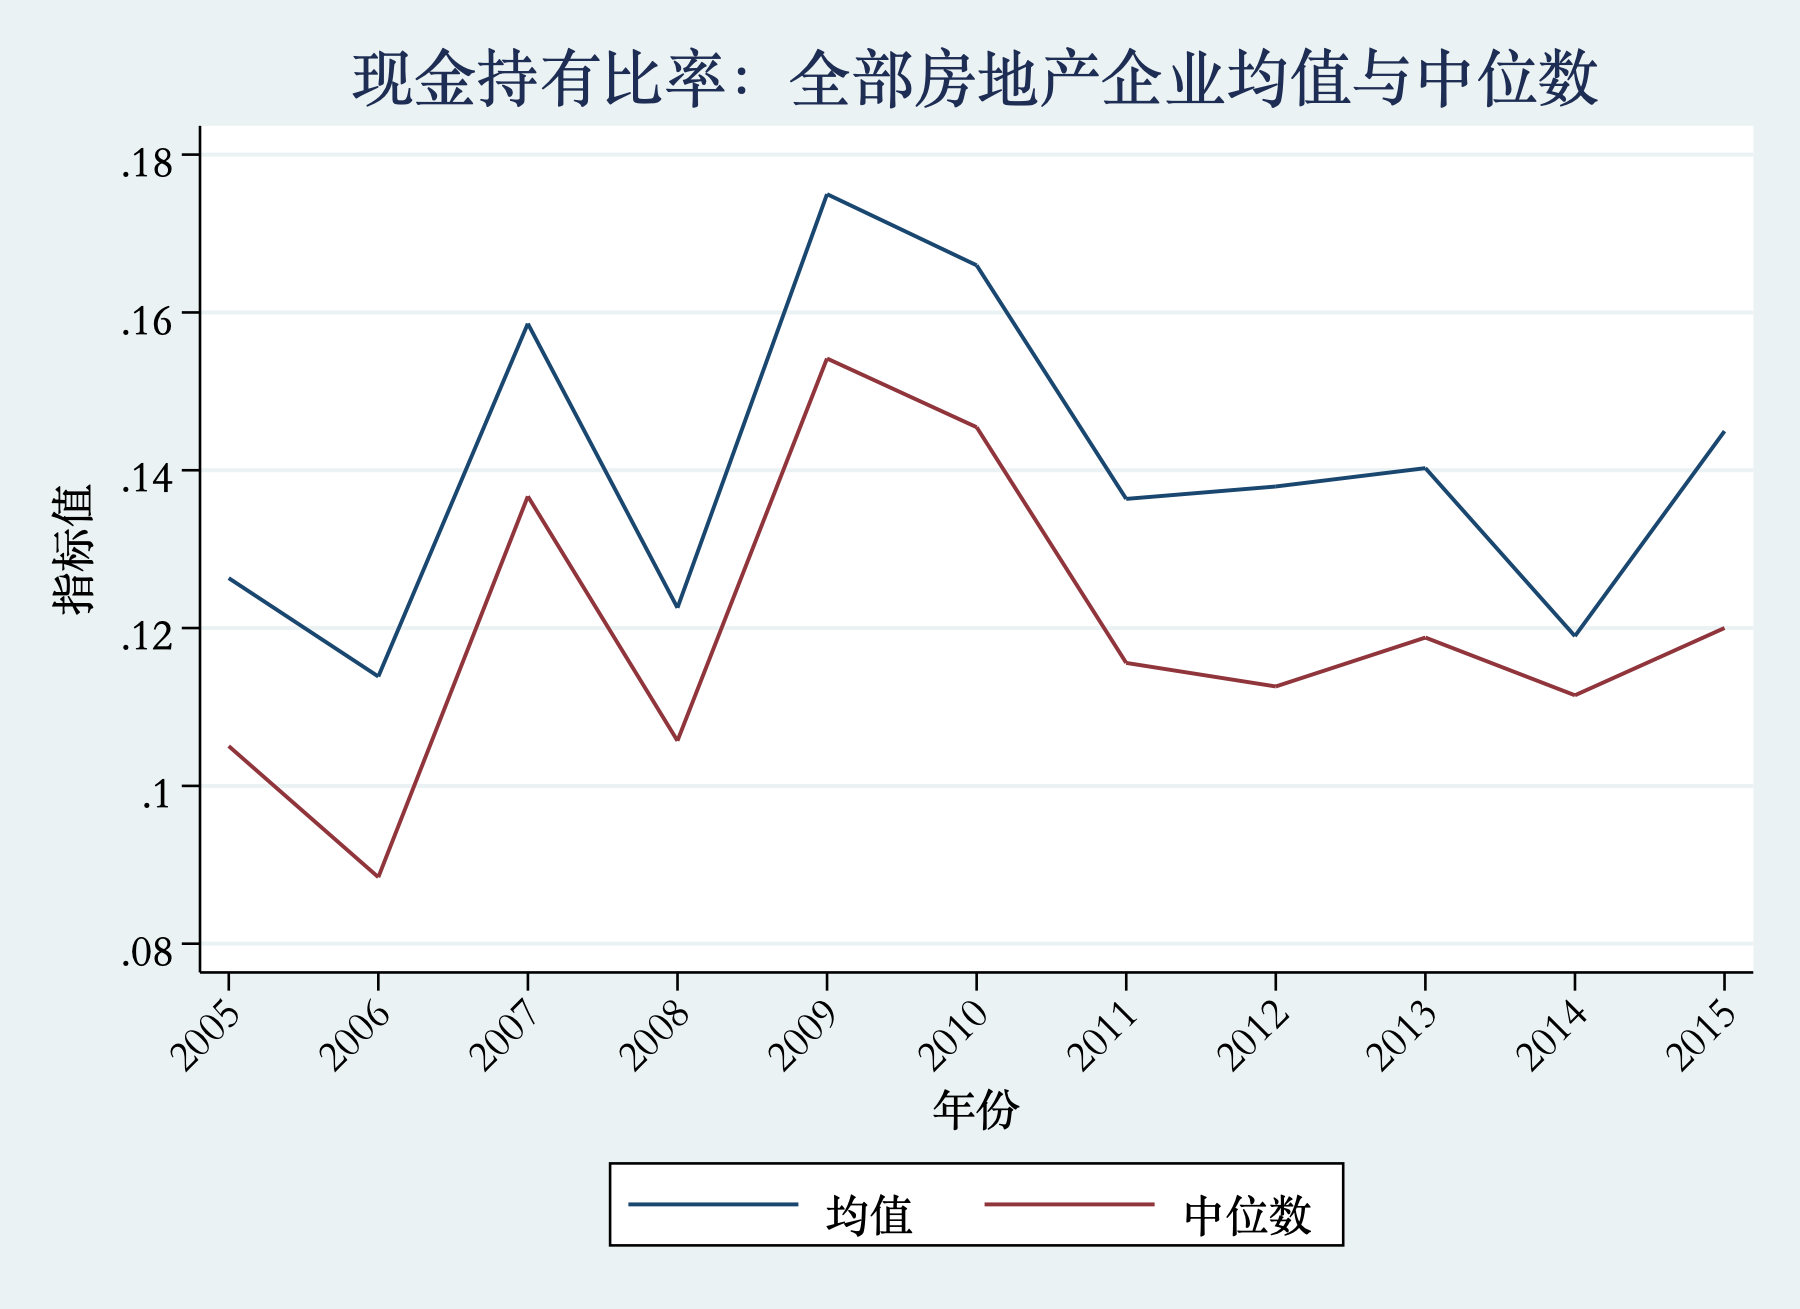

2005、2010 和 2015 年的关键指标如下：

| 指标 | 年份 | 有效样本量 | 均值（%） | 中位数（%） |
| --- | --- | --- | --- | --- |
| 资产负债率 | 2005 | 55 | 74.220 | 58.730 |
| 资产负债率 | 2010 | 102 | 70.240 | 67.160 |
| 资产负债率 | 2015 | 109 | 63.530 | 66.060 |
| 银行贷款占比 | 2005 | 55 | 45.740 | 47.900 |
| 银行贷款占比 | 2010 | 102 | 31.240 | 30.150 |
| 银行贷款占比 | 2015 | 109 | 30.140 | 27.310 |
| 短期负债占比 | 2005 | 55 | 84.640 | 87.780 |
| 短期负债占比 | 2010 | 102 | 72.250 | 74.220 |
| 短期负债占比 | 2015 | 109 | 70.310 | 69.180 |
| ROA | 2005 | 55 | 0.950 | 2.080 |
| ROA | 2010 | 102 | 3.730 | 4.050 |
| ROA | 2015 | 107 | 0.940 | 1.730 |
| ROE | 2005 | 53 | 4.420 | 4.850 |
| ROE | 2010 | 101 | 7.940 | 12.590 |
| ROE | 2015 | 106 | 3.590 | 5.880 |
| 现金持有比率 | 2005 | 55 | 12.630 | 10.500 |
| 现金持有比率 | 2010 | 102 | 16.600 | 14.550 |
| 现金持有比率 | 2015 | 109 | 14.500 | 12.000 |

### Step 3：结果解读

资产负债率均值在 2009 年达到较高水平，随后回落；2015 年均值约为 63.53%，中位数约为 66.06%。2009 年均值明显受极端公司影响，例如 `600603 ST 兴业` 的资产负债率异常高，因此中位数更能代表典型房地产企业的杠杆水平。银行贷款占比从 2005 年均值 45.74% 下降到 2015 年 30.14%，说明样本公司负债来源中银行借款占比下降，但这只是描述性变化，不能单独说明融资渠道因果变化。

短期负债占比从 2005 年均值 84.64% 下降到 2015 年 70.31%，说明流动负债仍占较高比例，但短期偿债压力相对有所缓和。ROA 和 ROE 在 2007 年较高，2015 年下降明显：ROA 均值约 0.94%，ROE 均值约 3.59%。盈利能力下降可能与行业周期、样本进出和个别亏损公司有关。现金持有比率在 2009 年均值较高，2015 年为 14.50%，中位数为 12.00%，均值高于中位数说明部分公司现金持有较高。

核心发现：

- 资产负债率均值受极端值影响较强，中位数更平稳。
- 银行贷款占比和短期负债占比整体下降。
- ROA、ROE 在后期走弱，2015 年尤其明显。
- 均值与中位数差异提示离群值、异常分母和样本结构变化不可忽略。

## 4. 国有与民营企业财务特征比较

### Step 1：Markdown 分析说明

本环节比较国有和民营房地产企业的年度均值与年度中位数。比较时剔除“其他”类别，因为外资、混合性质和产权不明不适合归入国有或民营。这里的差异只是描述性差异，不能解释为产权造成的因果效应。

分析要点：

- 分别绘制国有和民营企业的均值比较图。
- 分别绘制国有和民营企业的中位数比较图。
- 关注均值与中位数是否给出不同结论。
- 结合异常值和样本量解释突变。

In [ ]:
local vars lev bankloan shortdebt roa roe cash_ta

foreach v of local vars {

    local cname "`v'"
    if "`v'" == "lev"       local cname "资产负债率"
    if "`v'" == "bankloan"  local cname "银行贷款占比"
    if "`v'" == "shortdebt" local cname "短期负债占比"
    if "`v'" == "roa"       local cname "ROA"
    if "`v'" == "roe"       local cname "ROE"
    if "`v'" == "cash_ta"   local cname "现金持有比率"

    preserve
        keep if inlist(owner_type, "国有", "民营")
        collapse (count) N = `v' (mean) mean = `v', by(year owner_type)
        export delimited using "`out'/`v'_国有民营均值表.csv", replace

        twoway ///
            (line mean year if owner_type == "国有", lcolor(navy)) ///
            (line mean year if owner_type == "民营", lcolor(maroon)), ///
            title("`cname'：国有与民营企业均值比较") ///
            xtitle("年份") ytitle("均值") ///
            xlabel(2005(1)2015, angle(45)) ///
            ylabel(, angle(0)) ///
            legend(order(1 "国有" 2 "民营"))
        graph export "`out'/`v'_国有民营均值比较.png", replace width(1800)
    restore

    preserve
        keep if inlist(owner_type, "国有", "民营")
        collapse (count) N = `v' (median) median = `v', by(year owner_type)
        export delimited using "`out'/`v'_国有民营中位数表.csv", replace

        twoway ///
            (line median year if owner_type == "国有", lcolor(navy)) ///
            (line median year if owner_type == "民营", lcolor(maroon)), ///
            title("`cname'：国有与民营企业中位数比较") ///
            xtitle("年份") ytitle("中位数") ///
            xlabel(2005(1)2015, angle(45)) ///
            ylabel(, angle(0)) ///
            legend(order(1 "国有" 2 "民营"))
        graph export "`out'/`v'_国有民营中位数比较.png", replace width(1800)
    restore
}

### 资产负债率：国有与民营企业均值比较

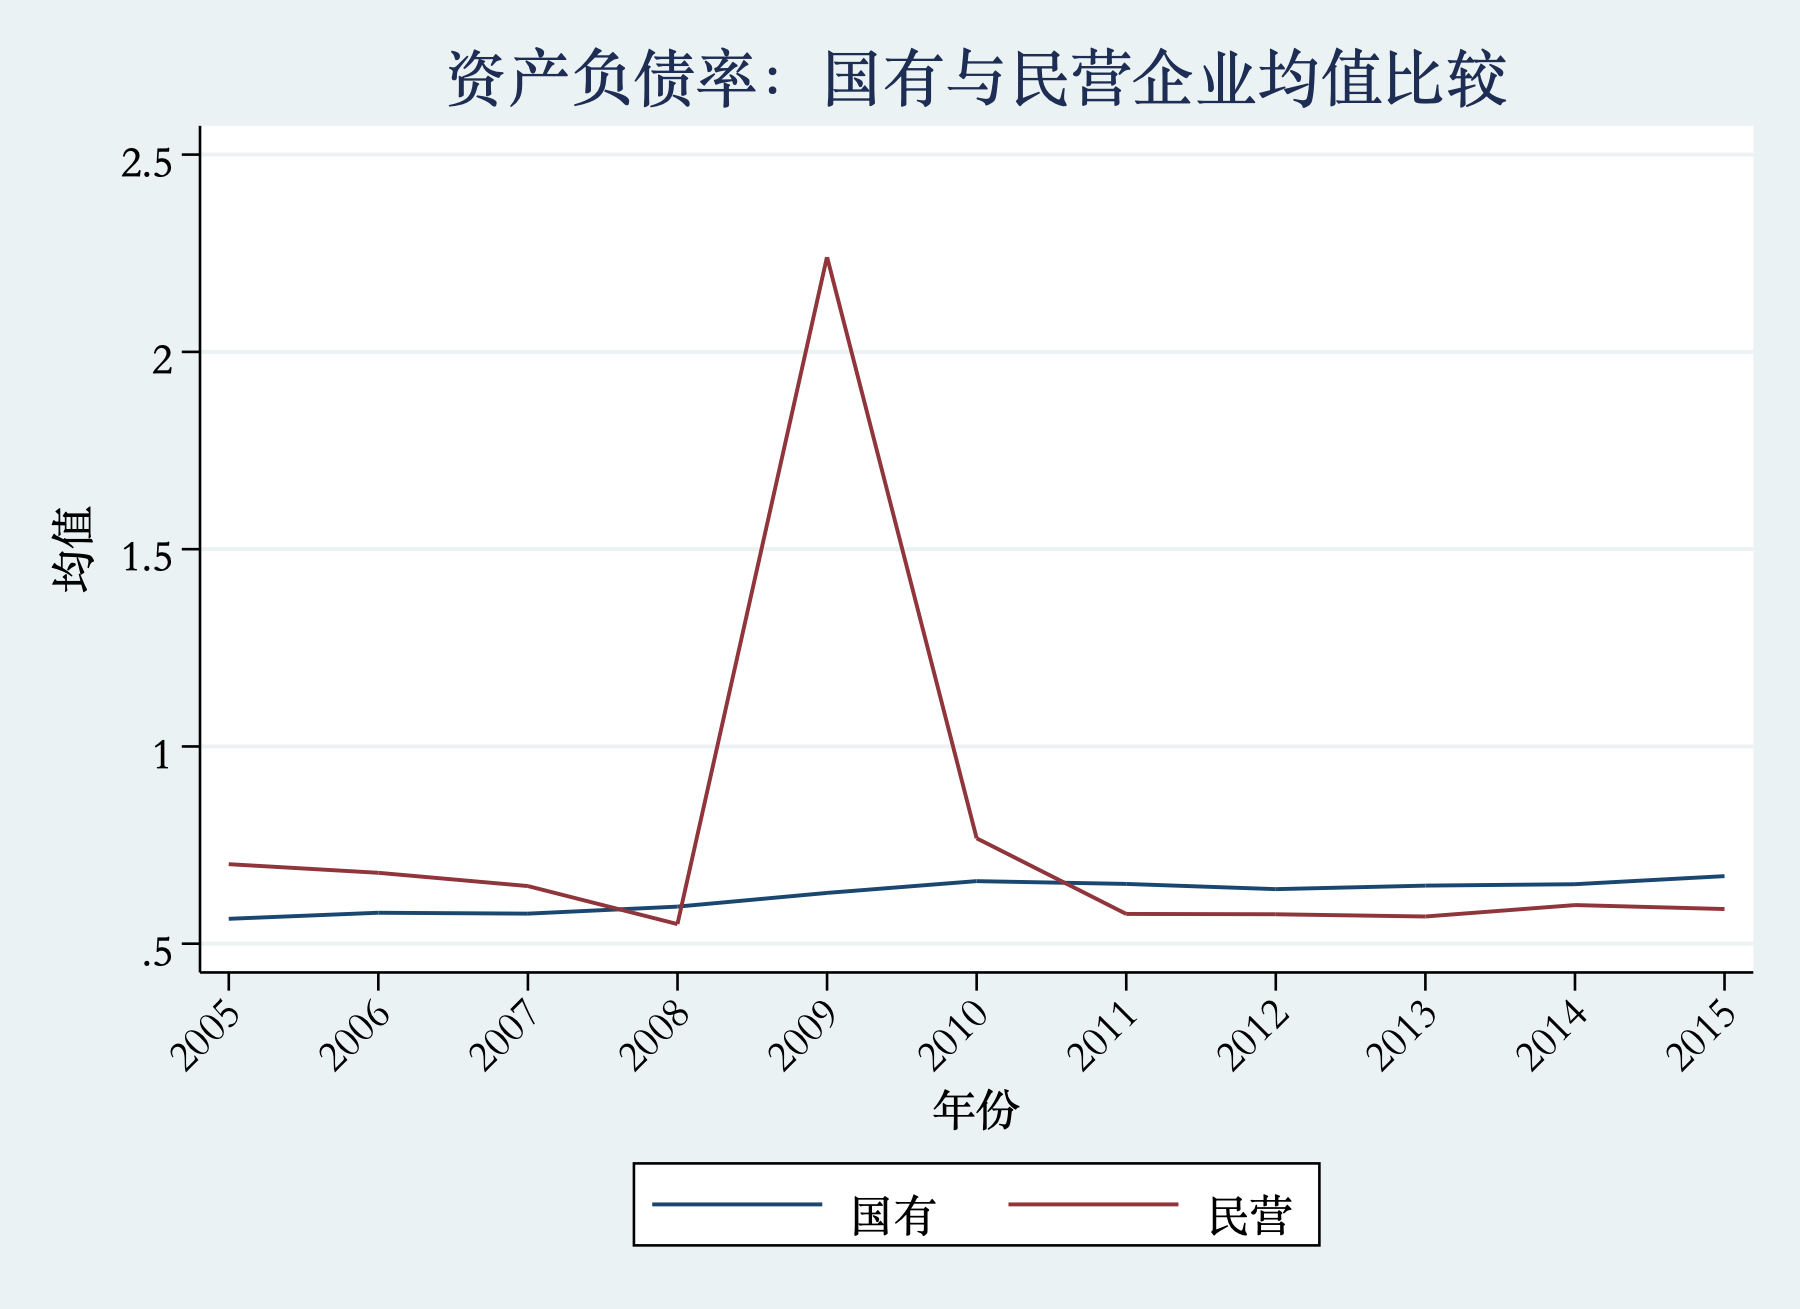

### 资产负债率：国有与民营企业中位数比较

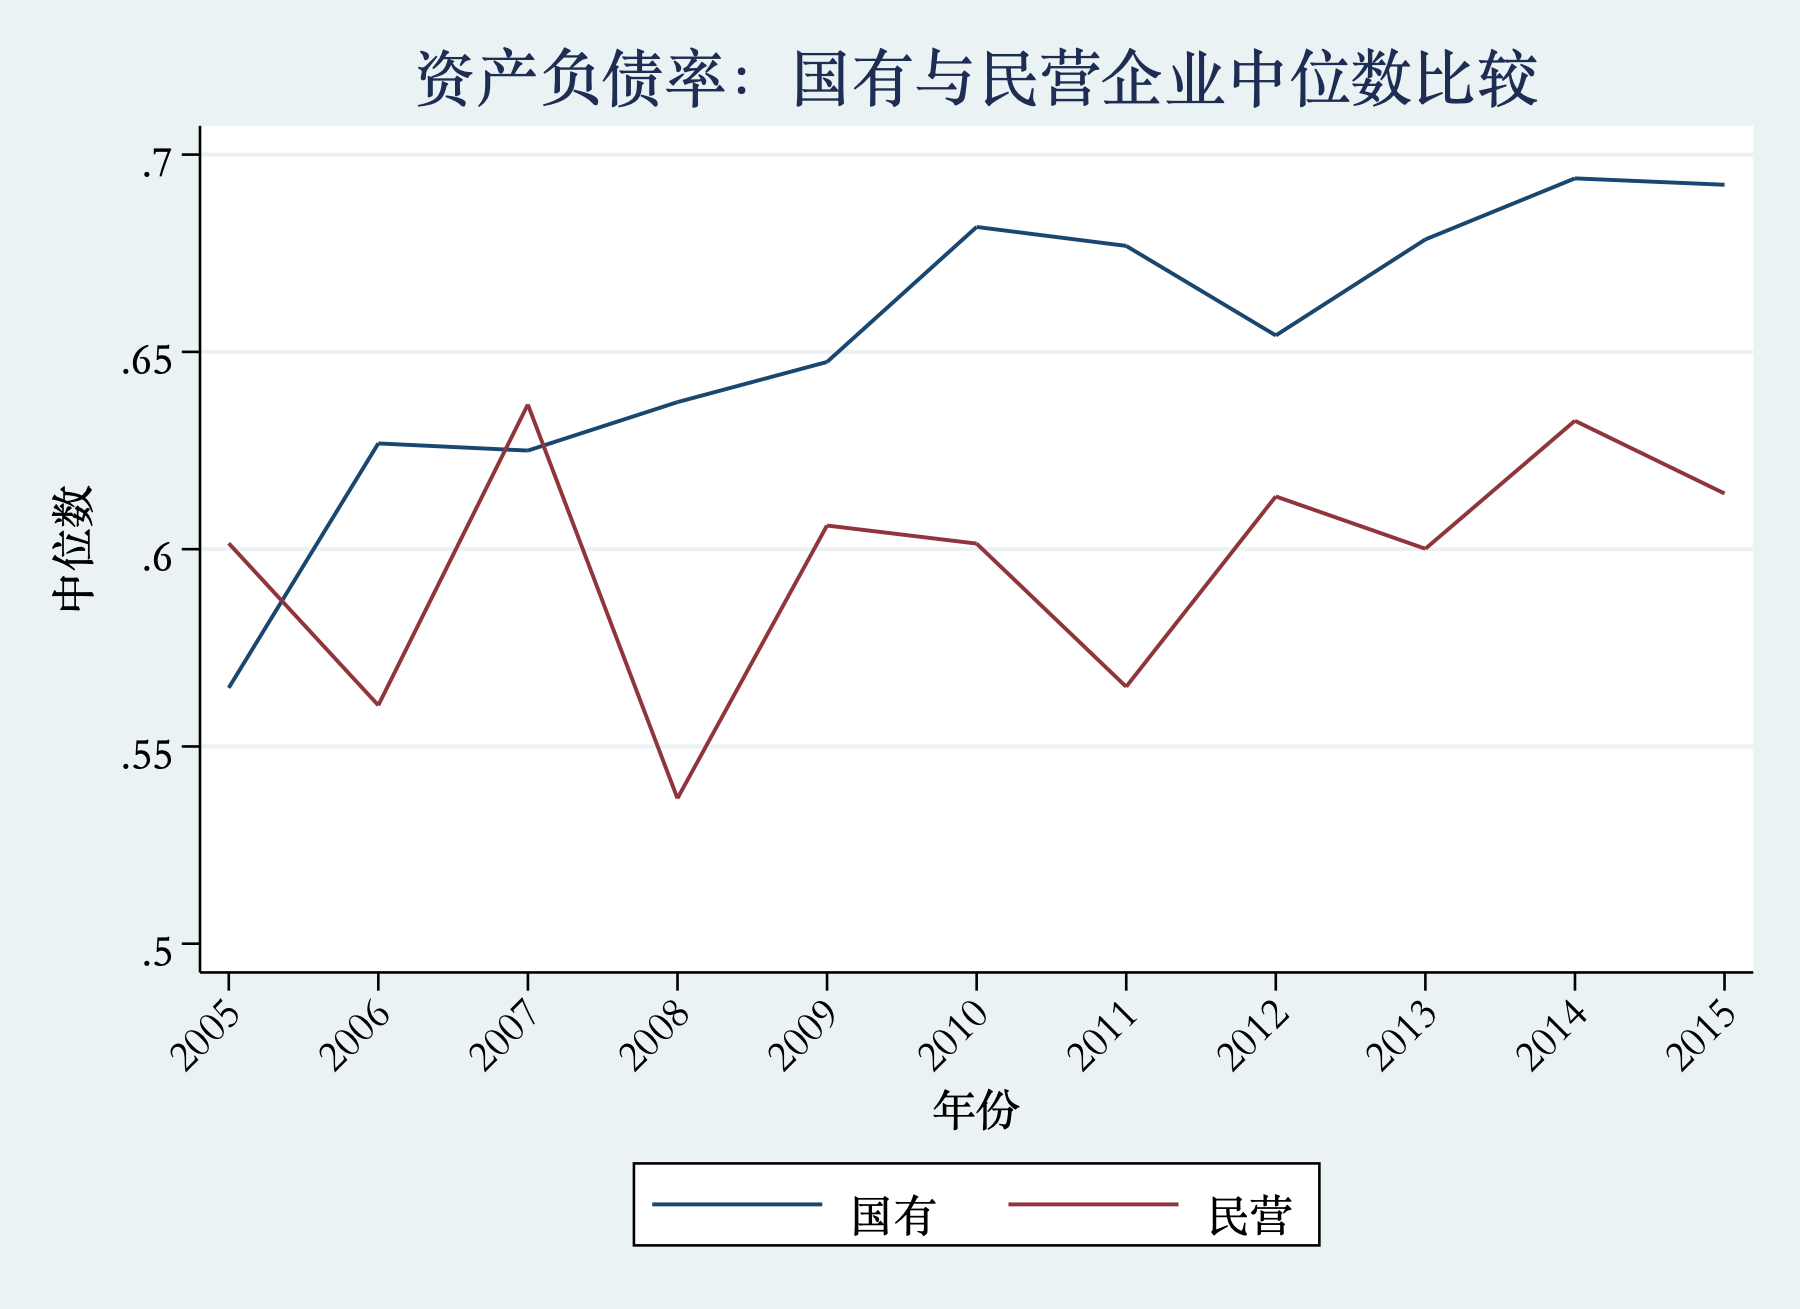

### 银行贷款占比：国有与民营企业均值比较

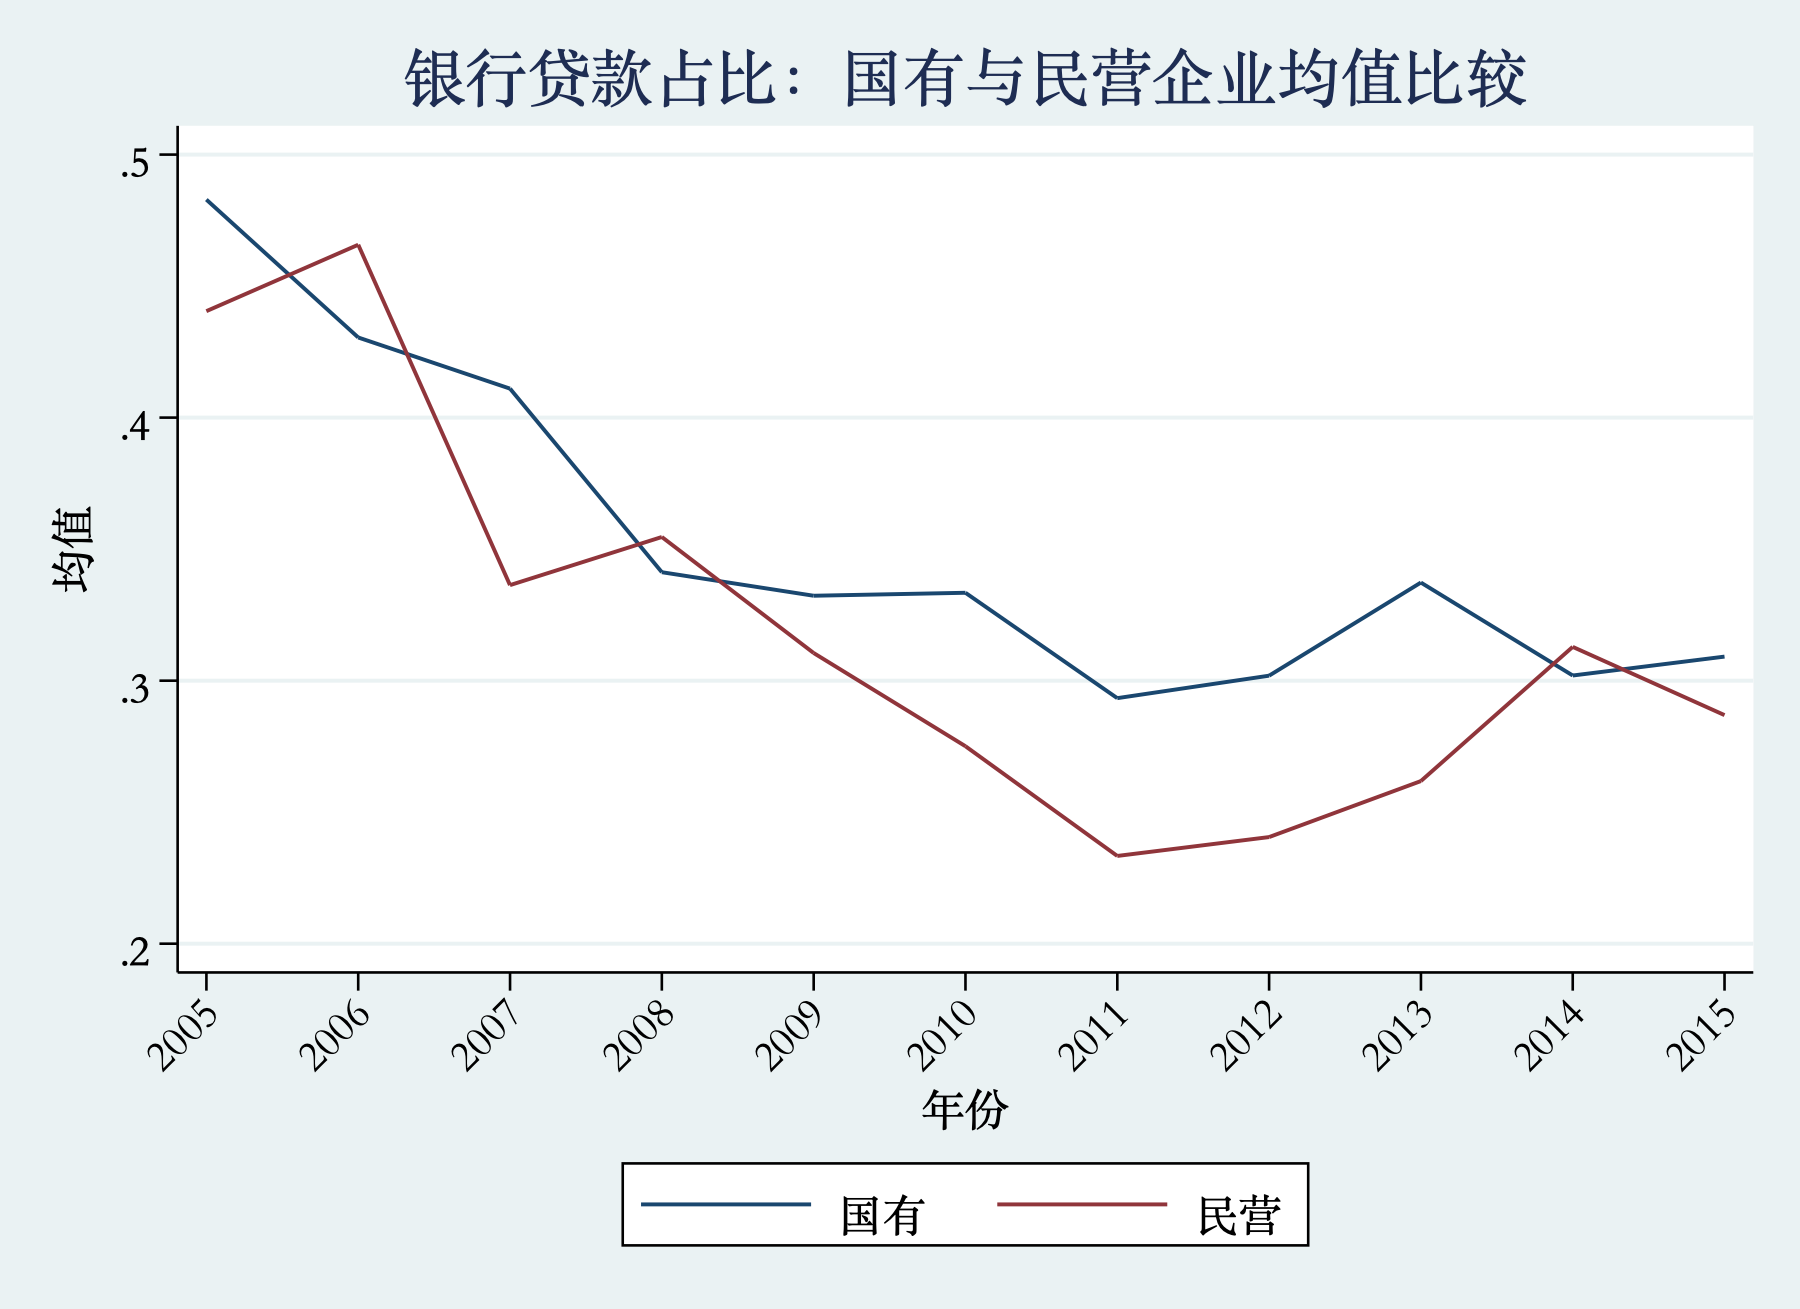

### 银行贷款占比：国有与民营企业中位数比较

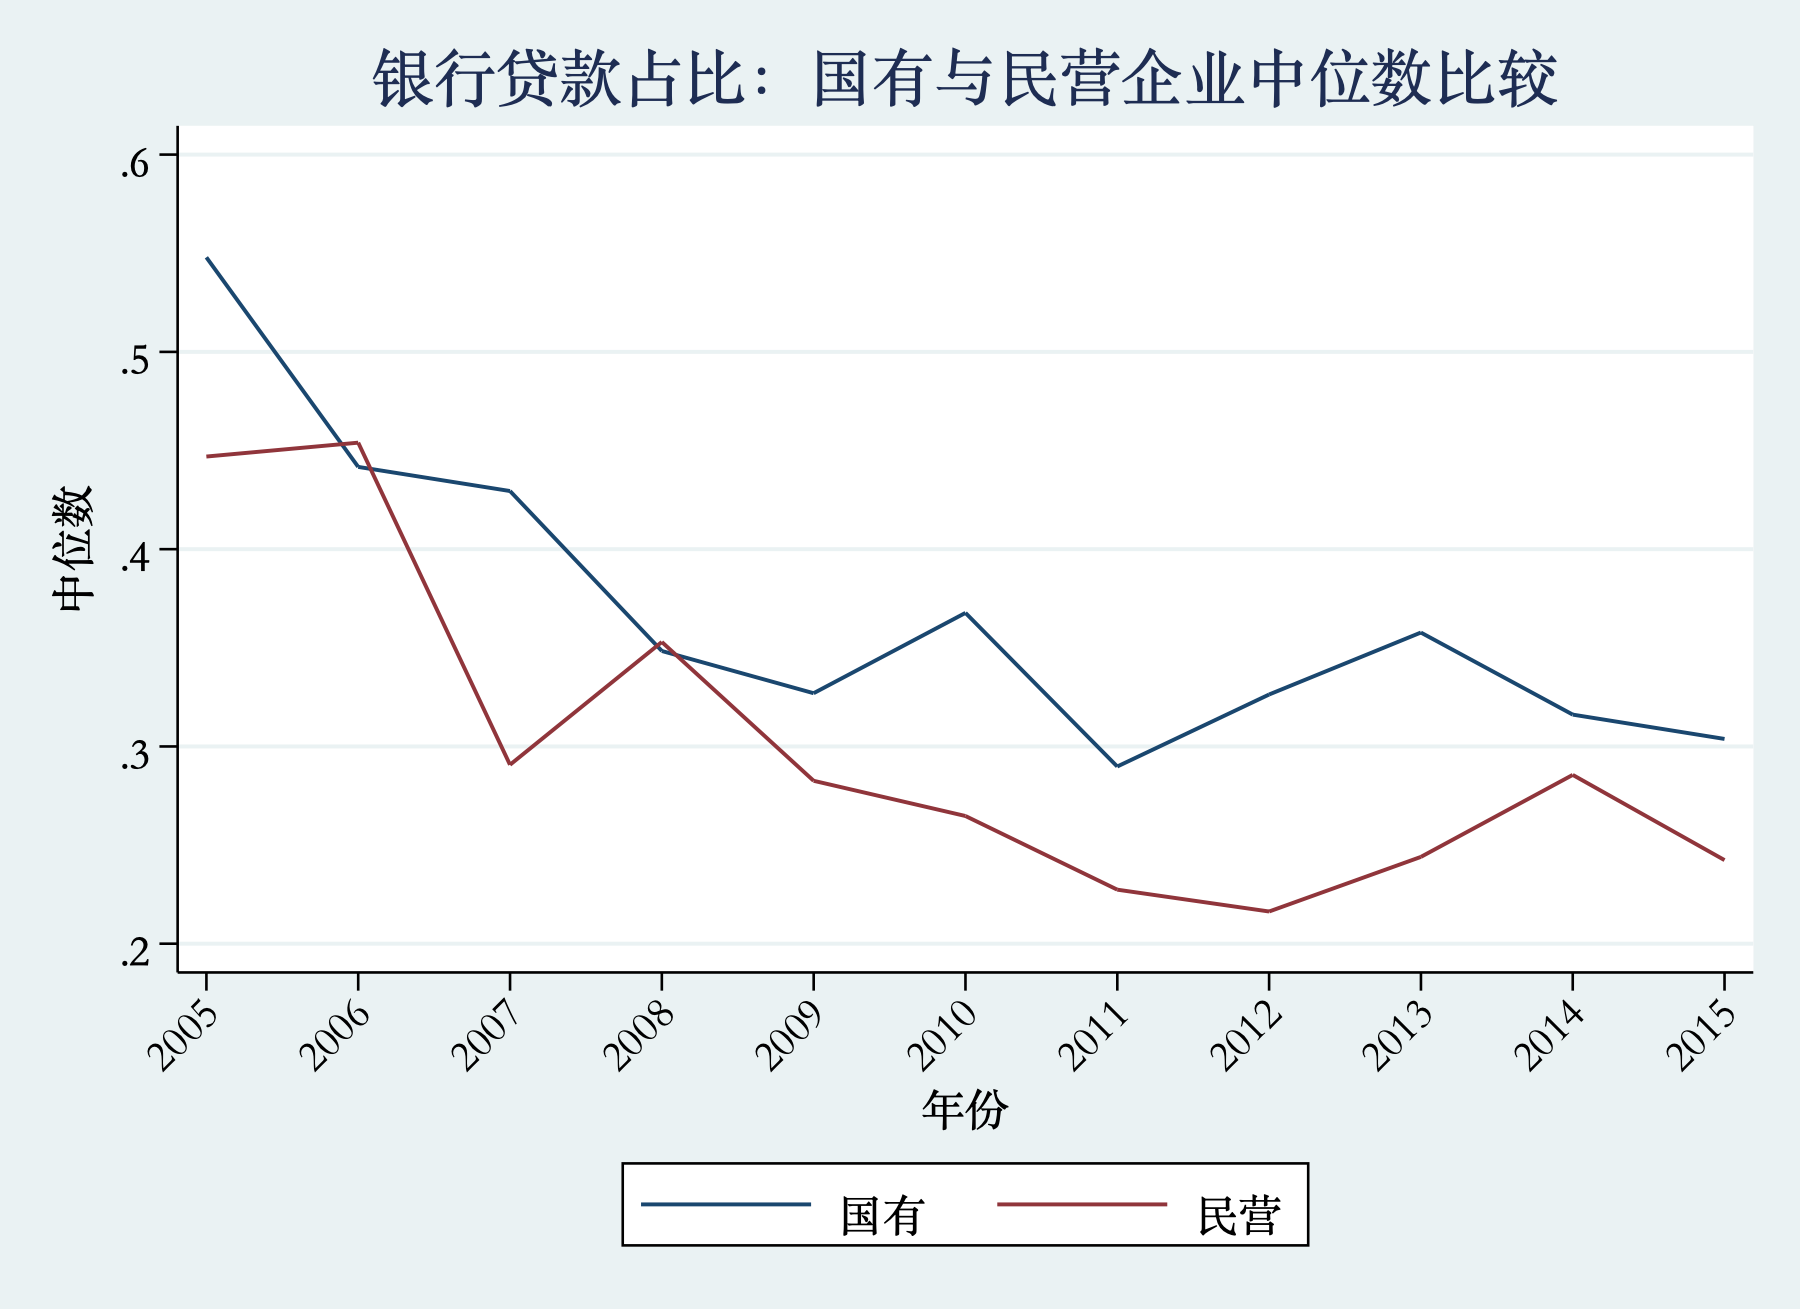

### 短期负债占比：国有与民营企业均值比较

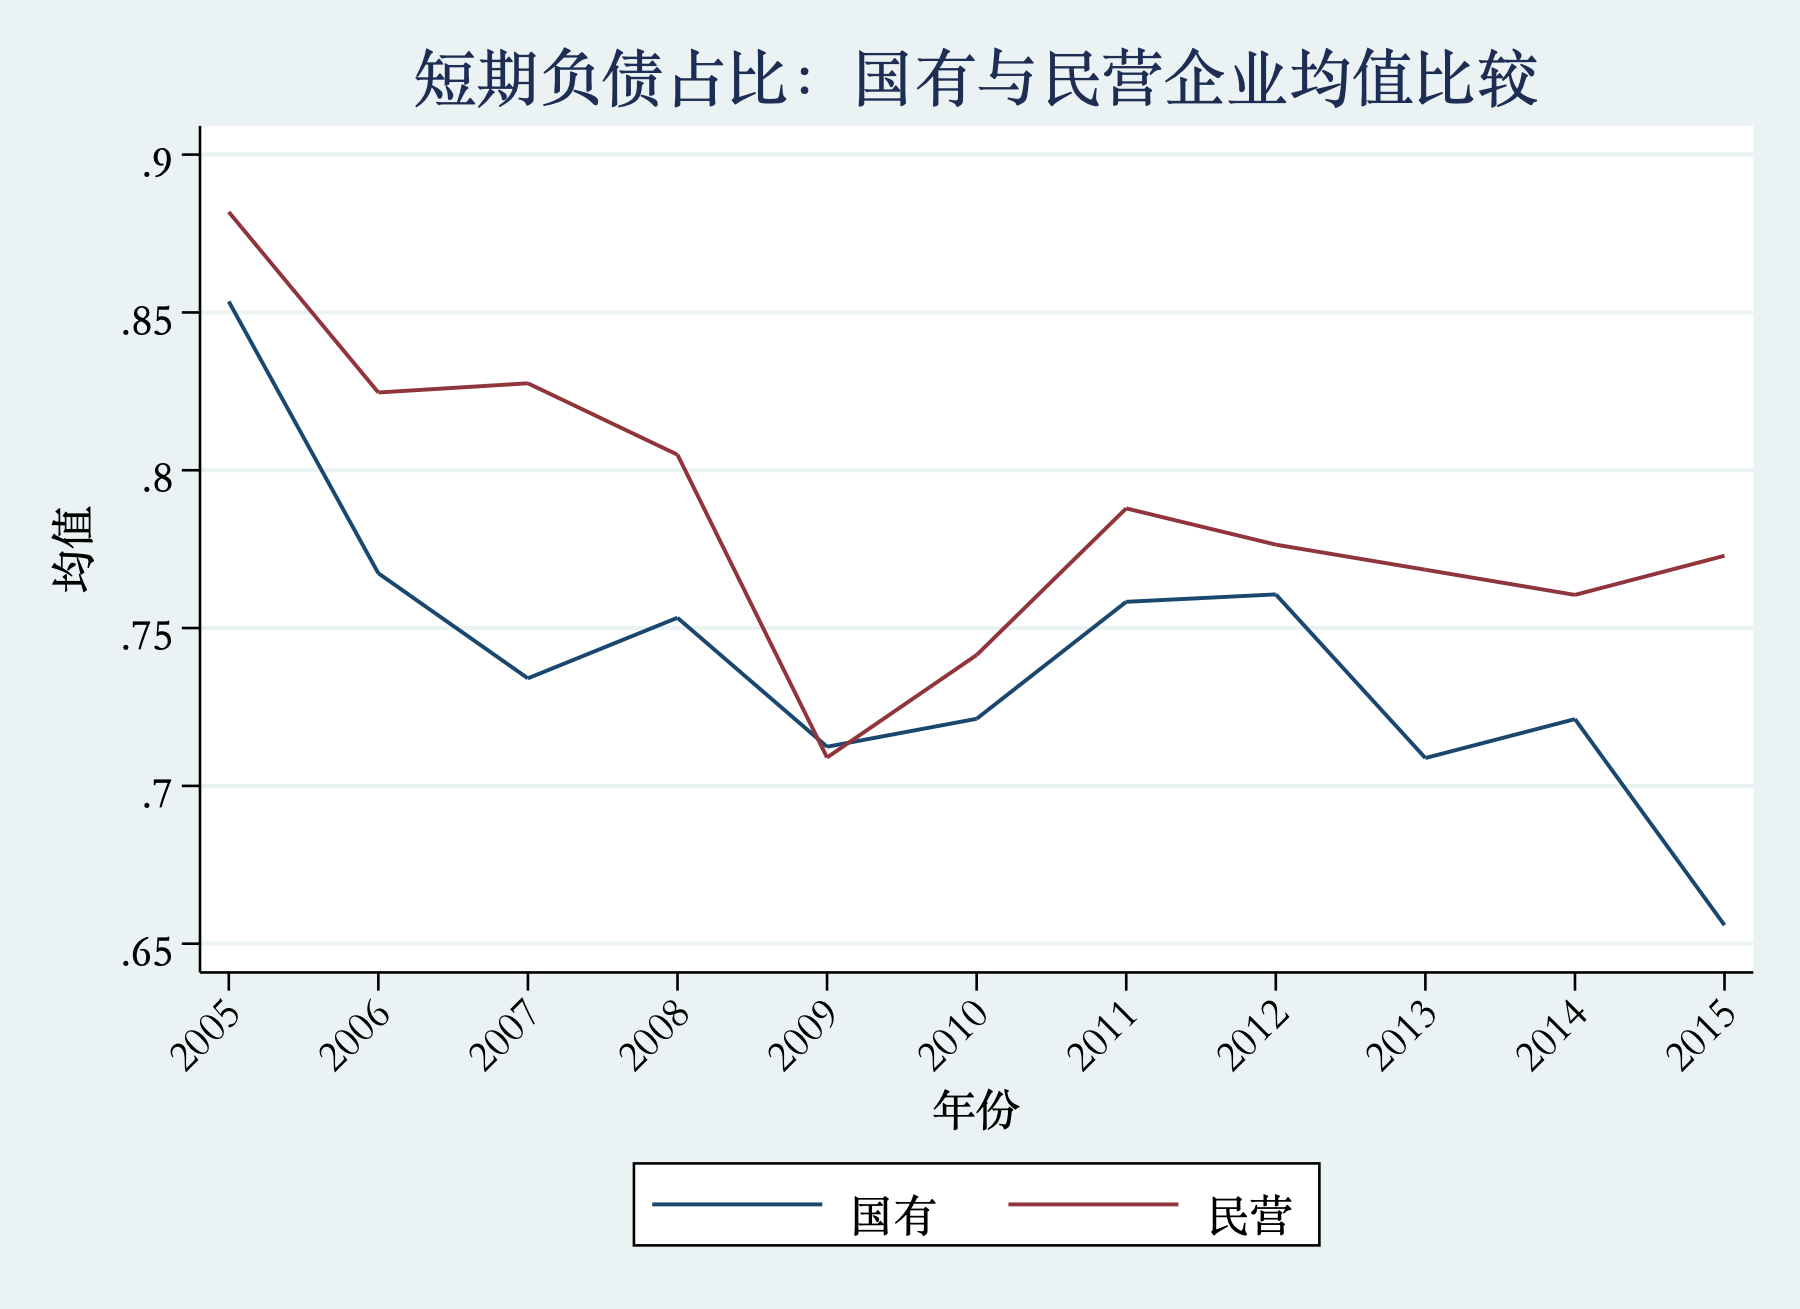

### 短期负债占比：国有与民营企业中位数比较

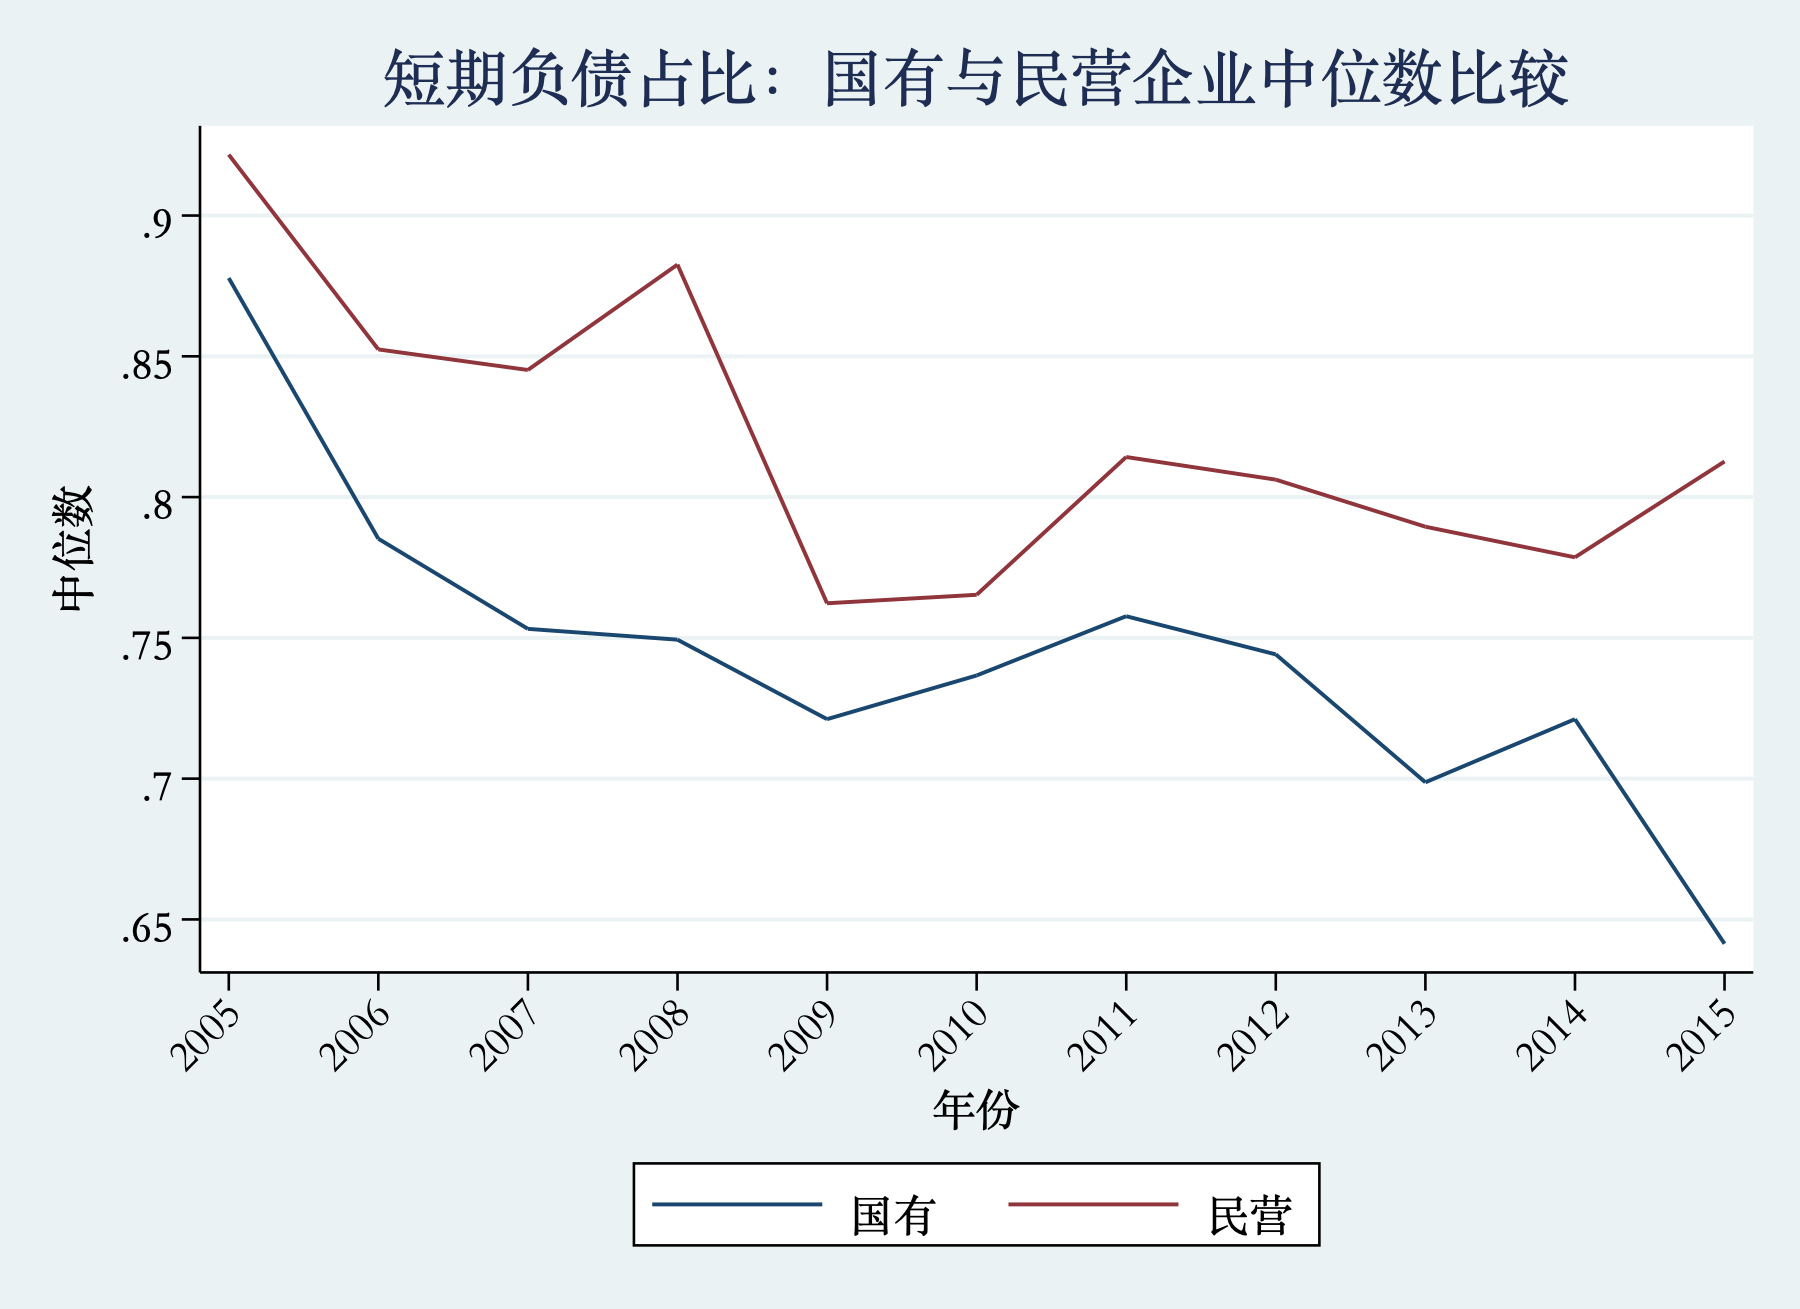

### ROA：国有与民营企业均值比较

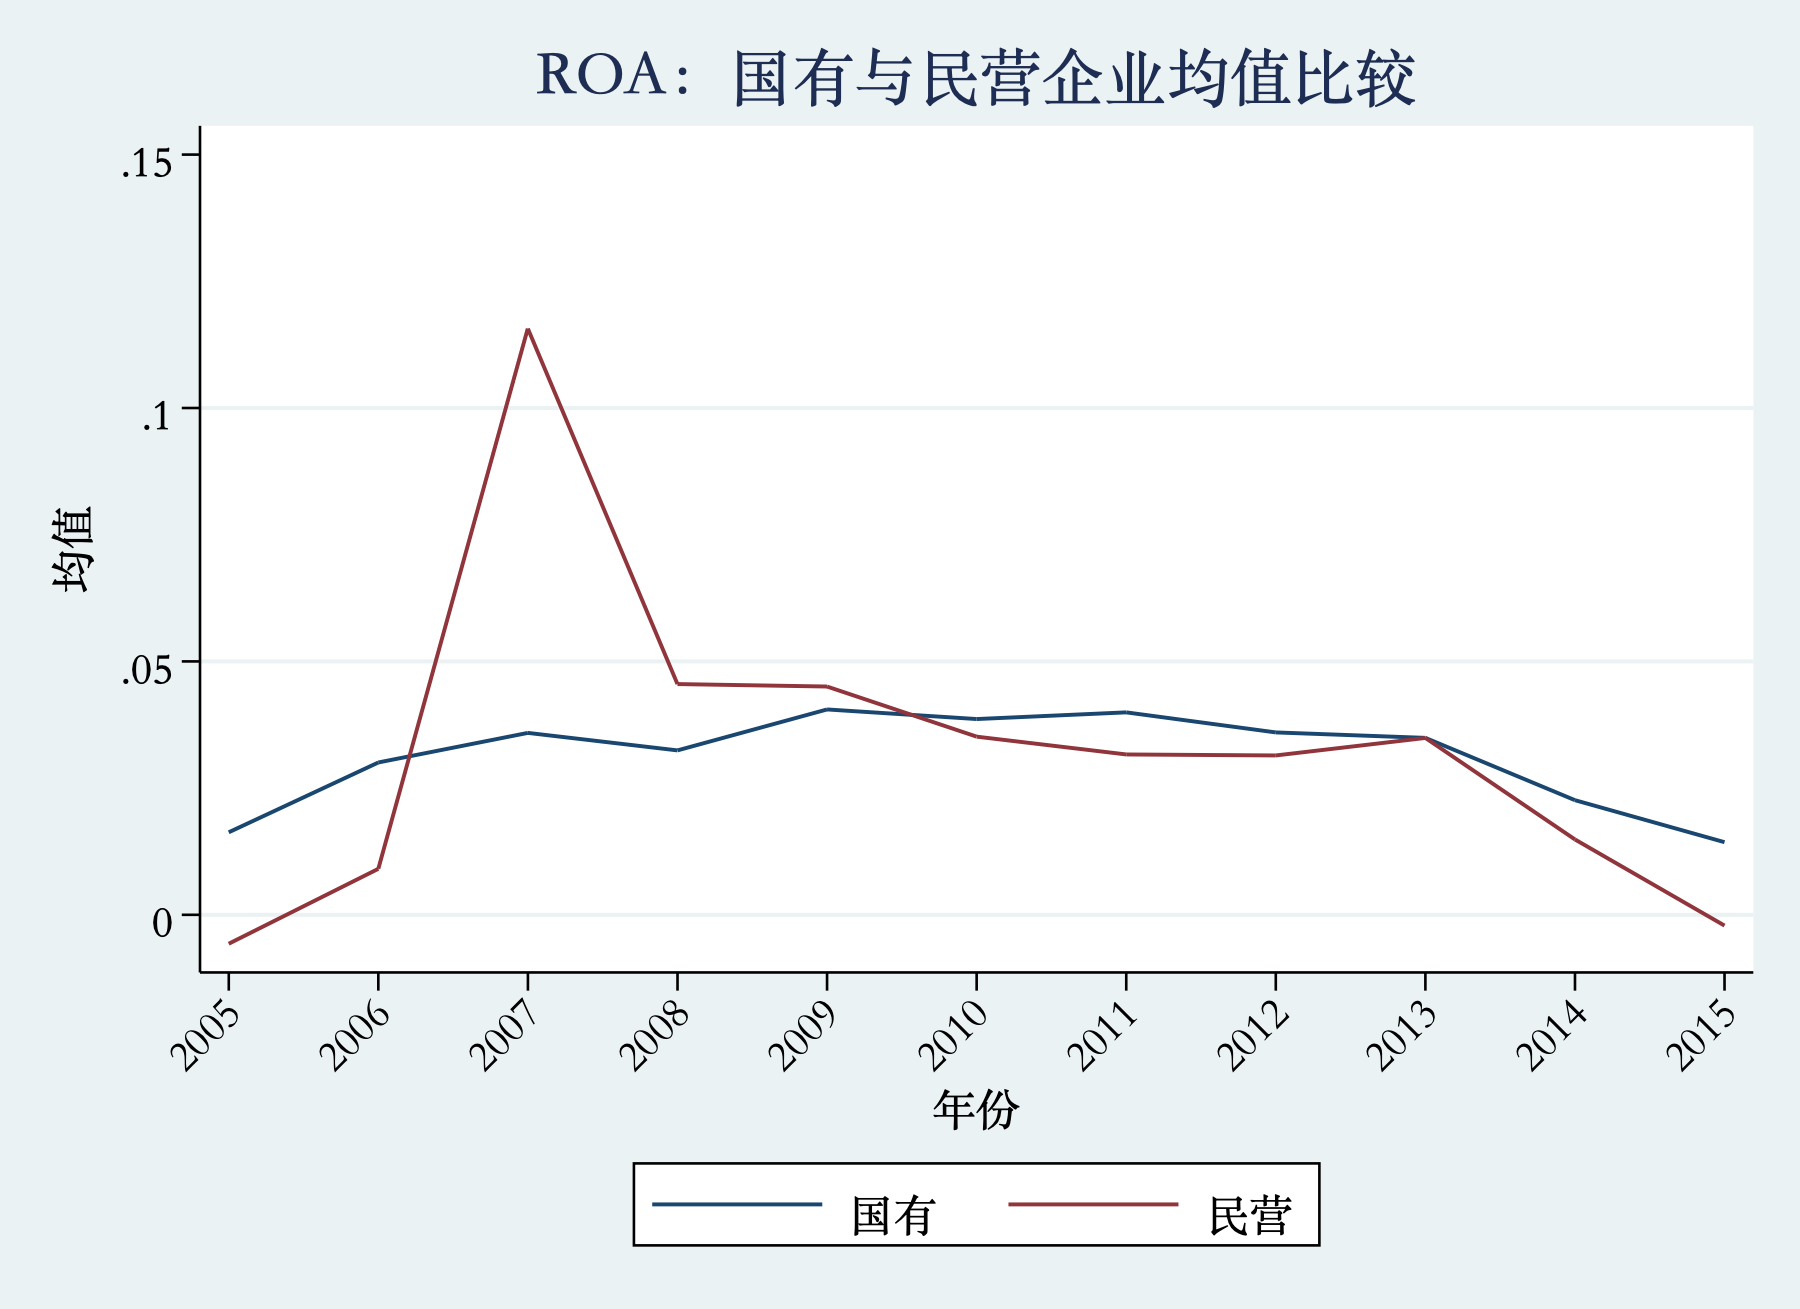

### ROA：国有与民营企业中位数比较

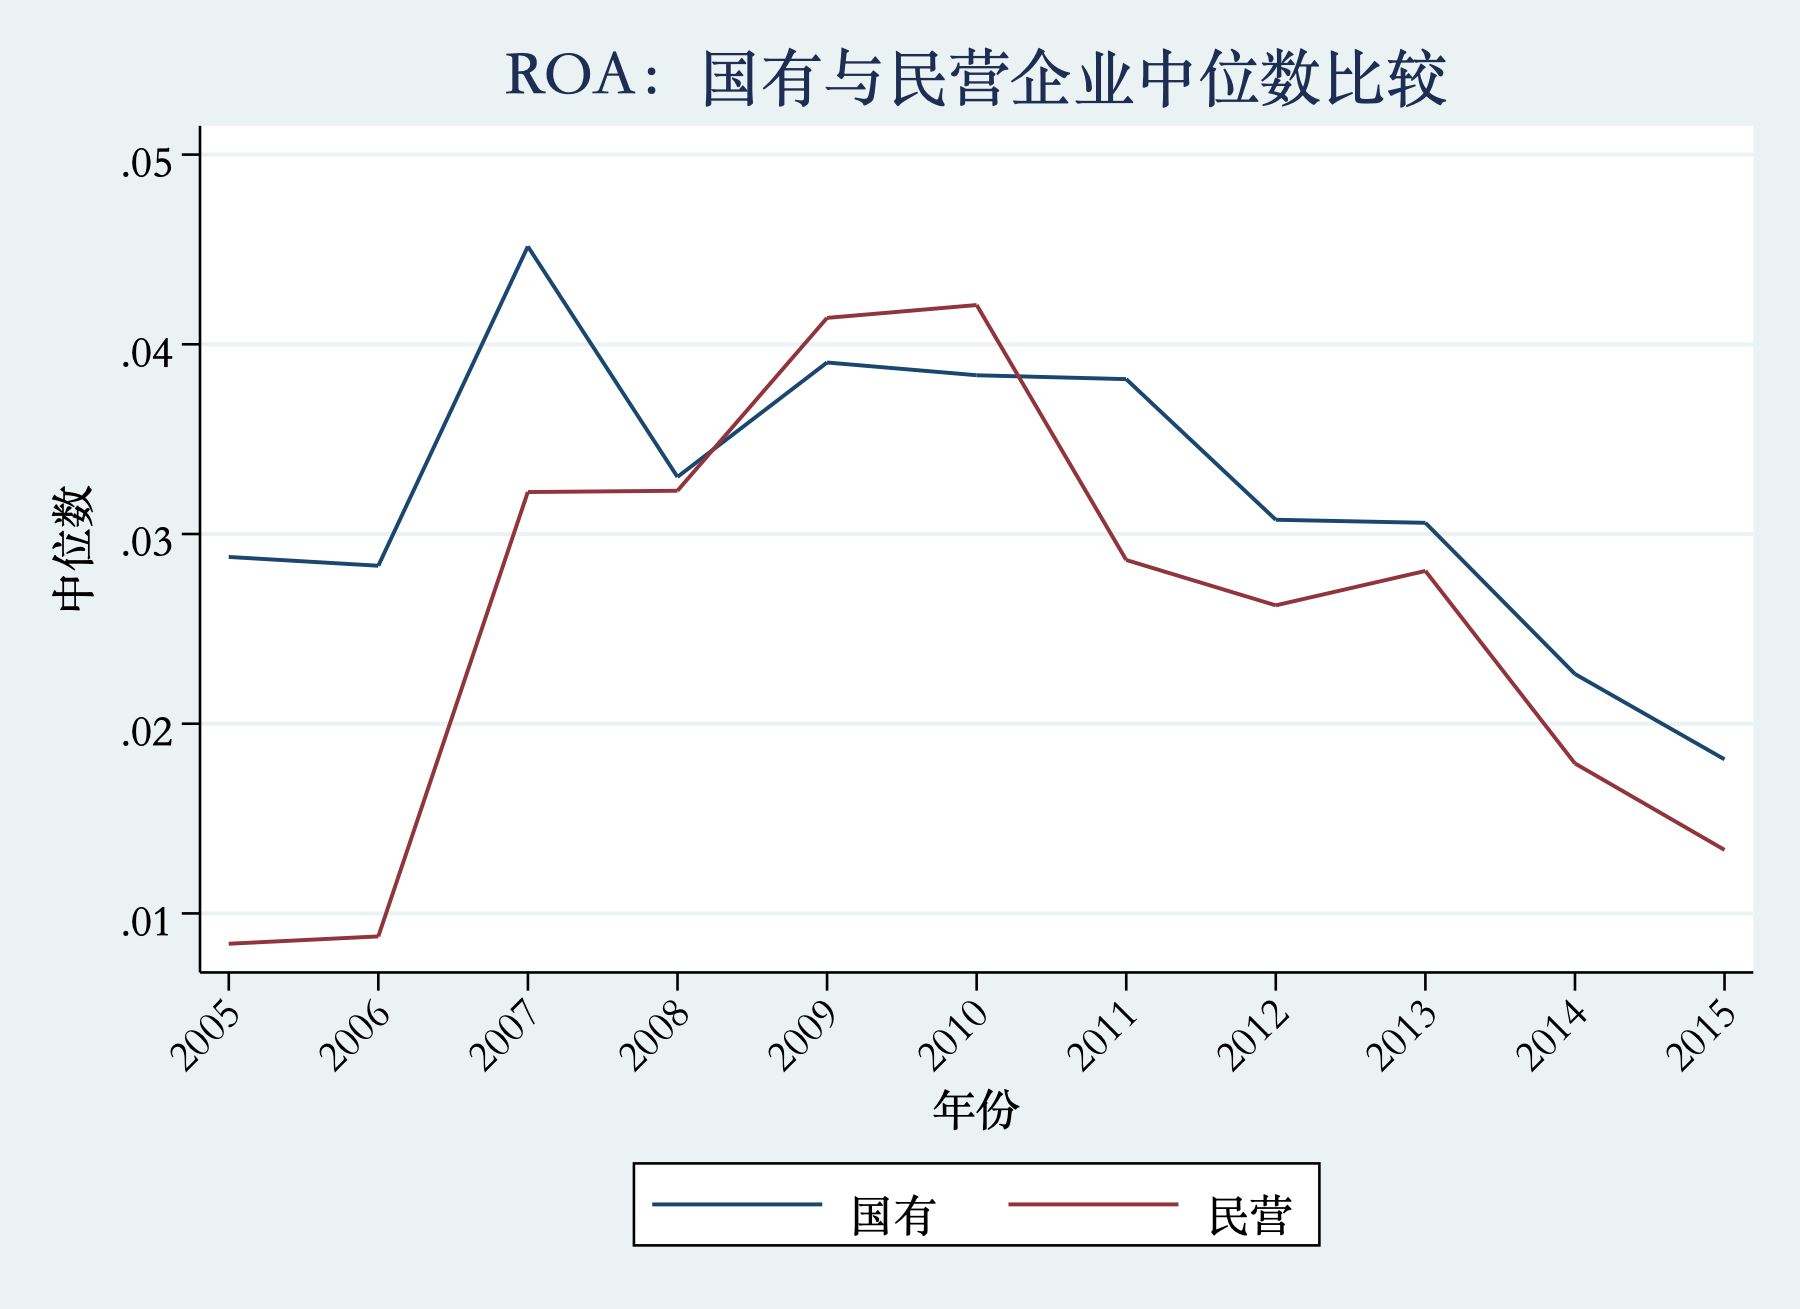

### ROE：国有与民营企业均值比较

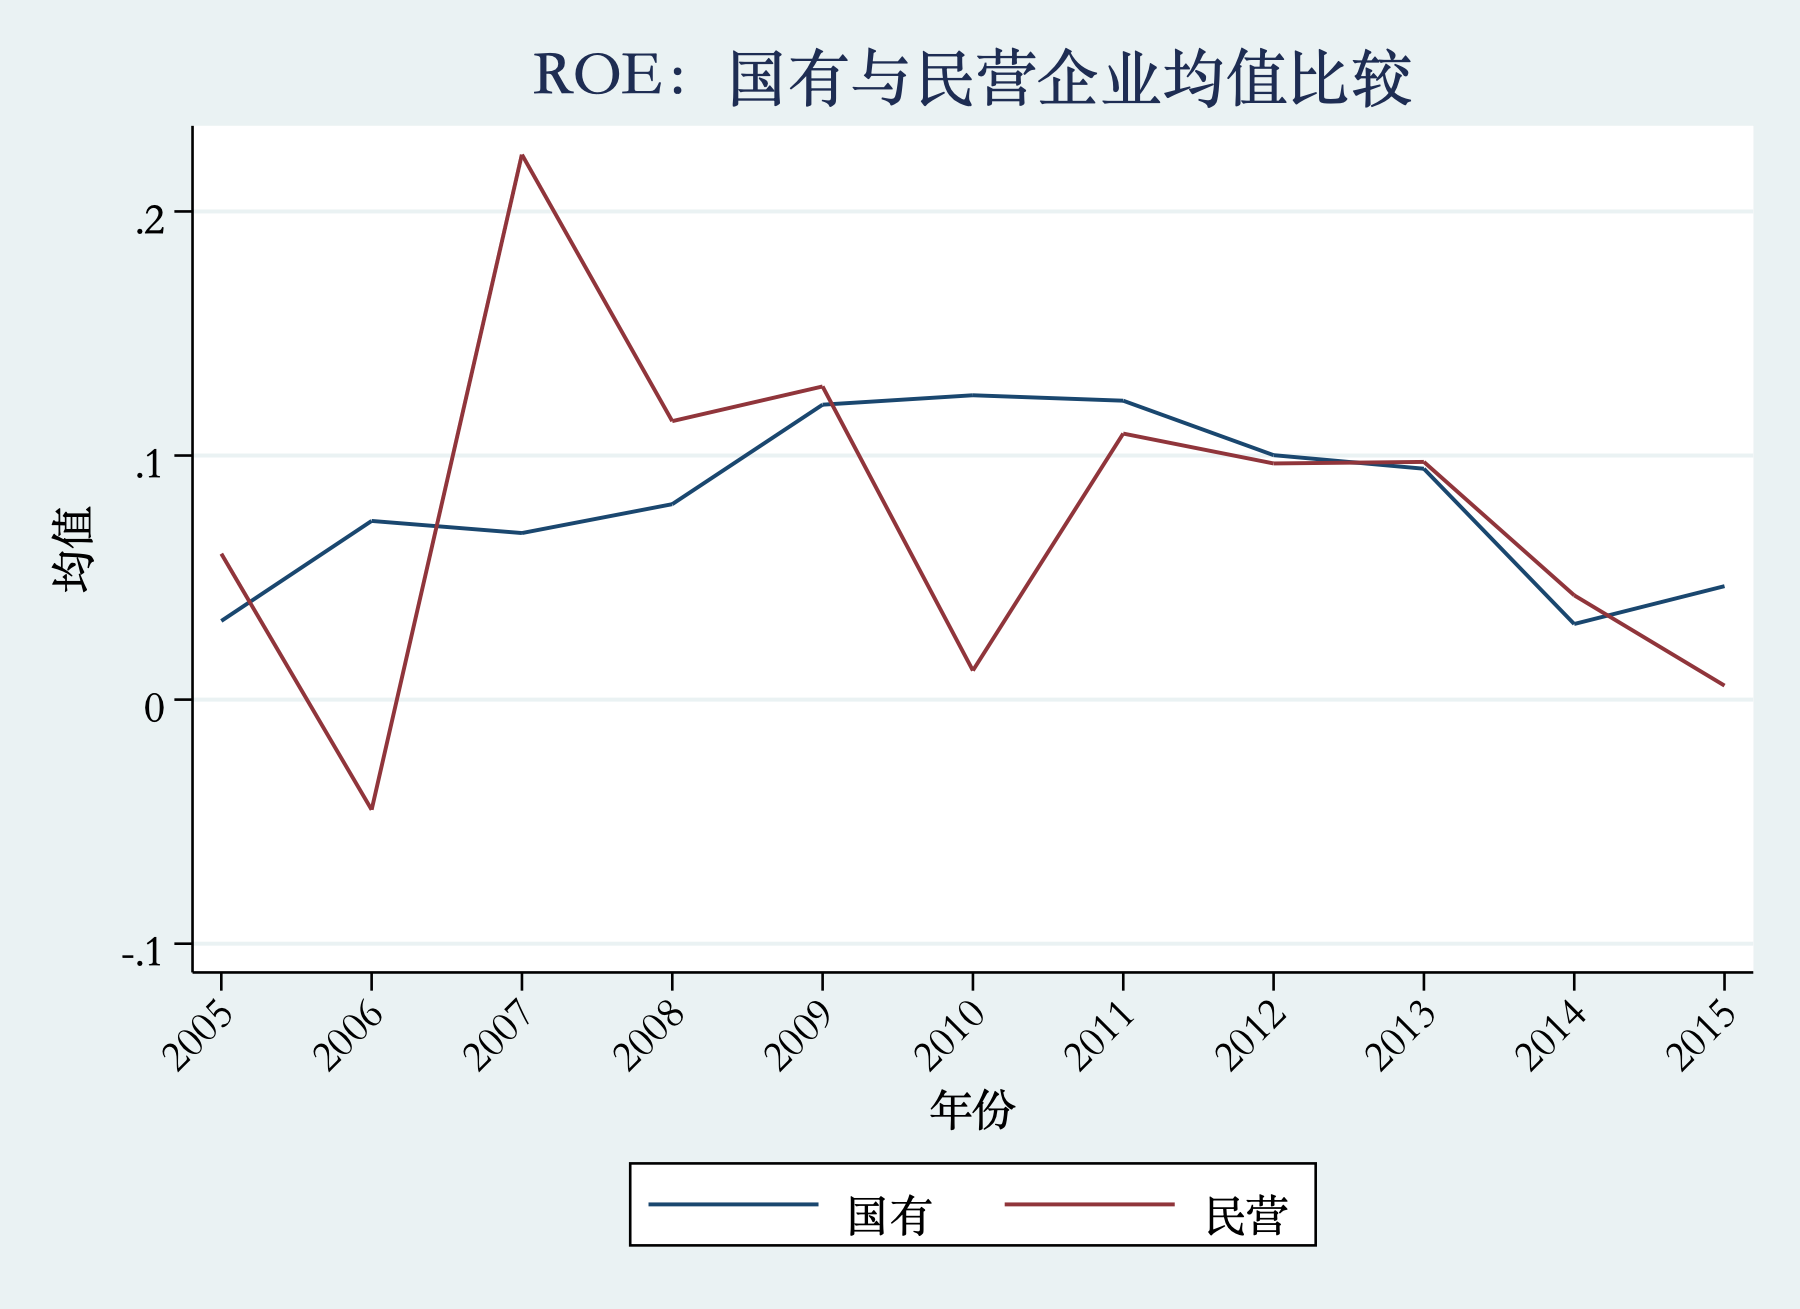

### ROE：国有与民营企业中位数比较

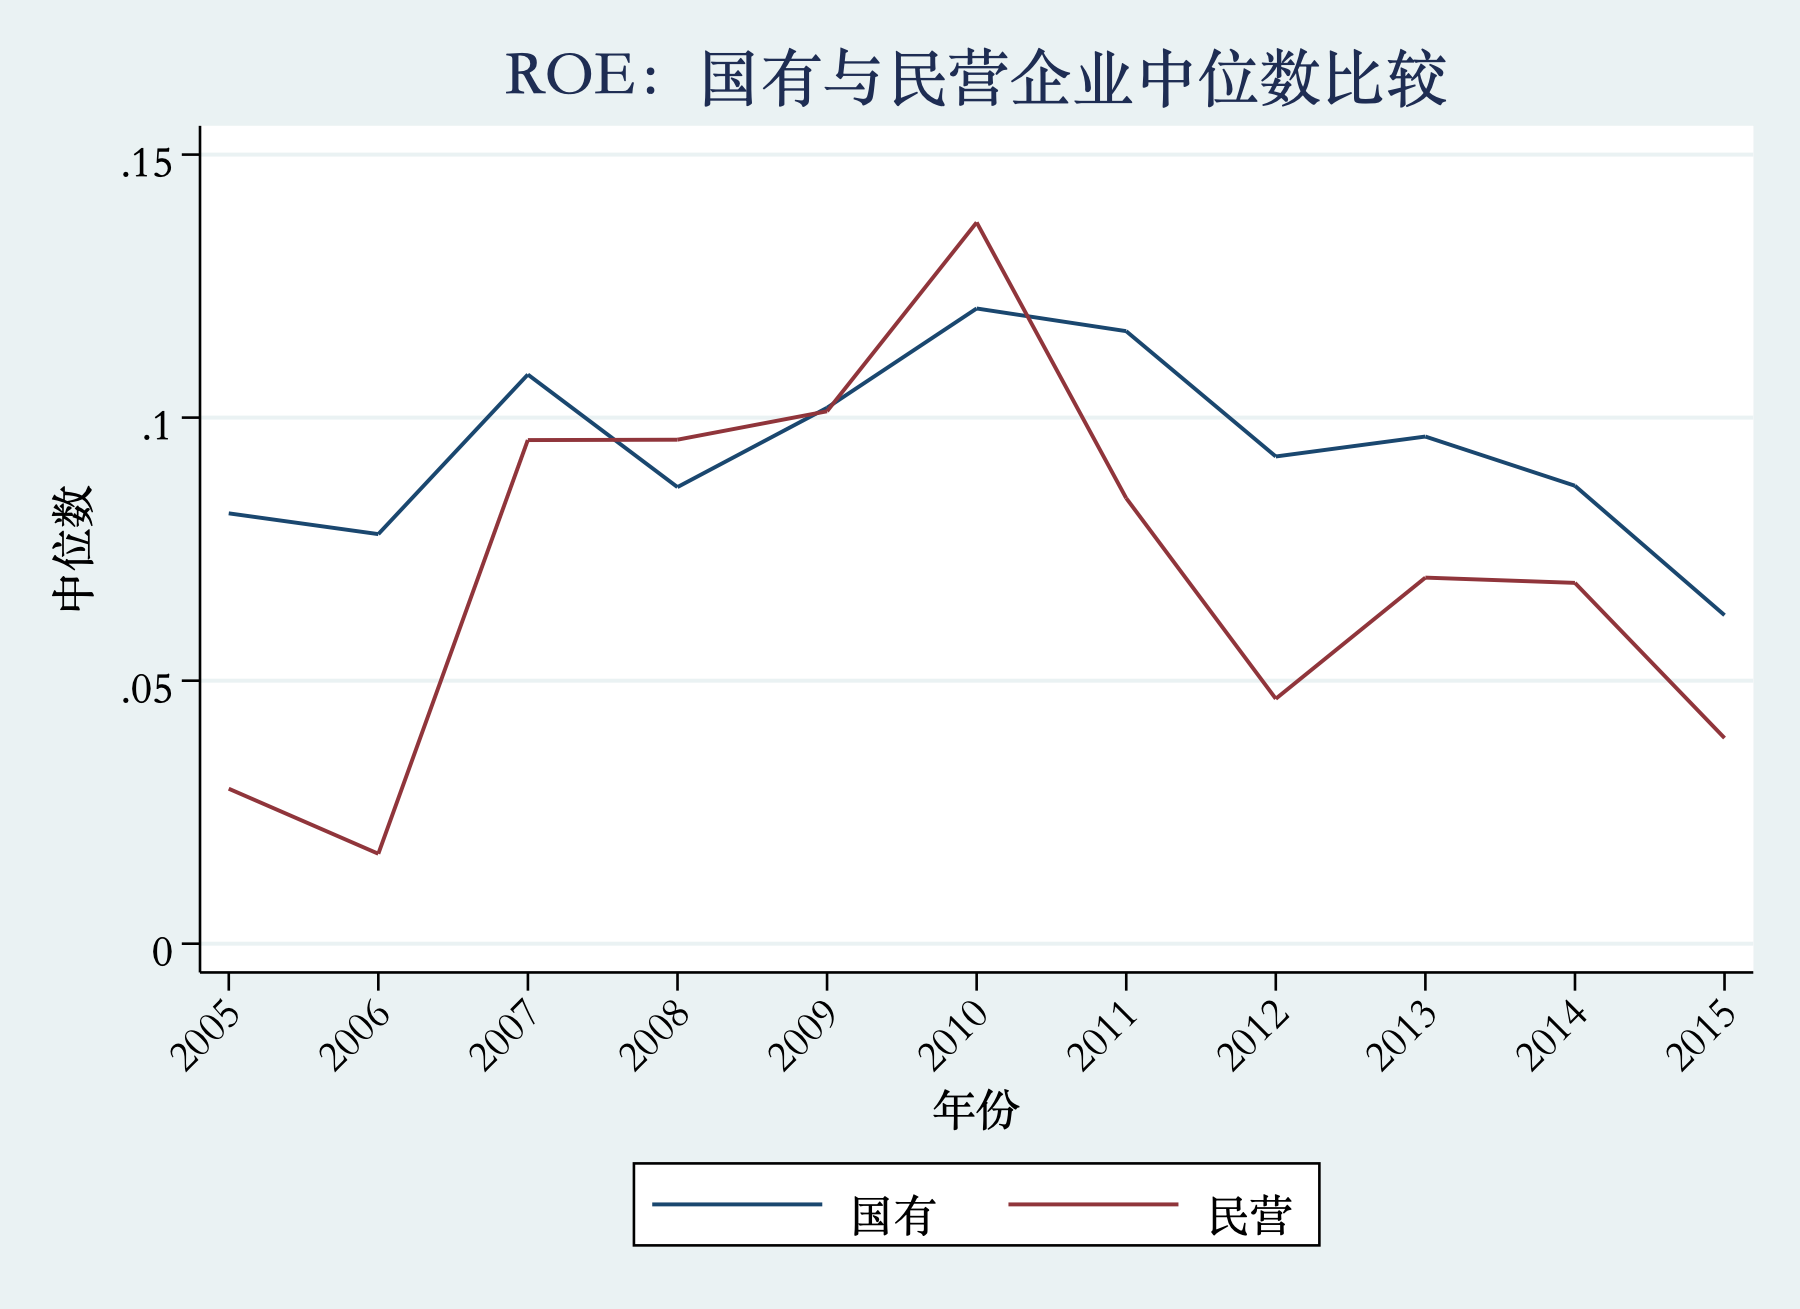

### 现金持有比率：国有与民营企业均值比较

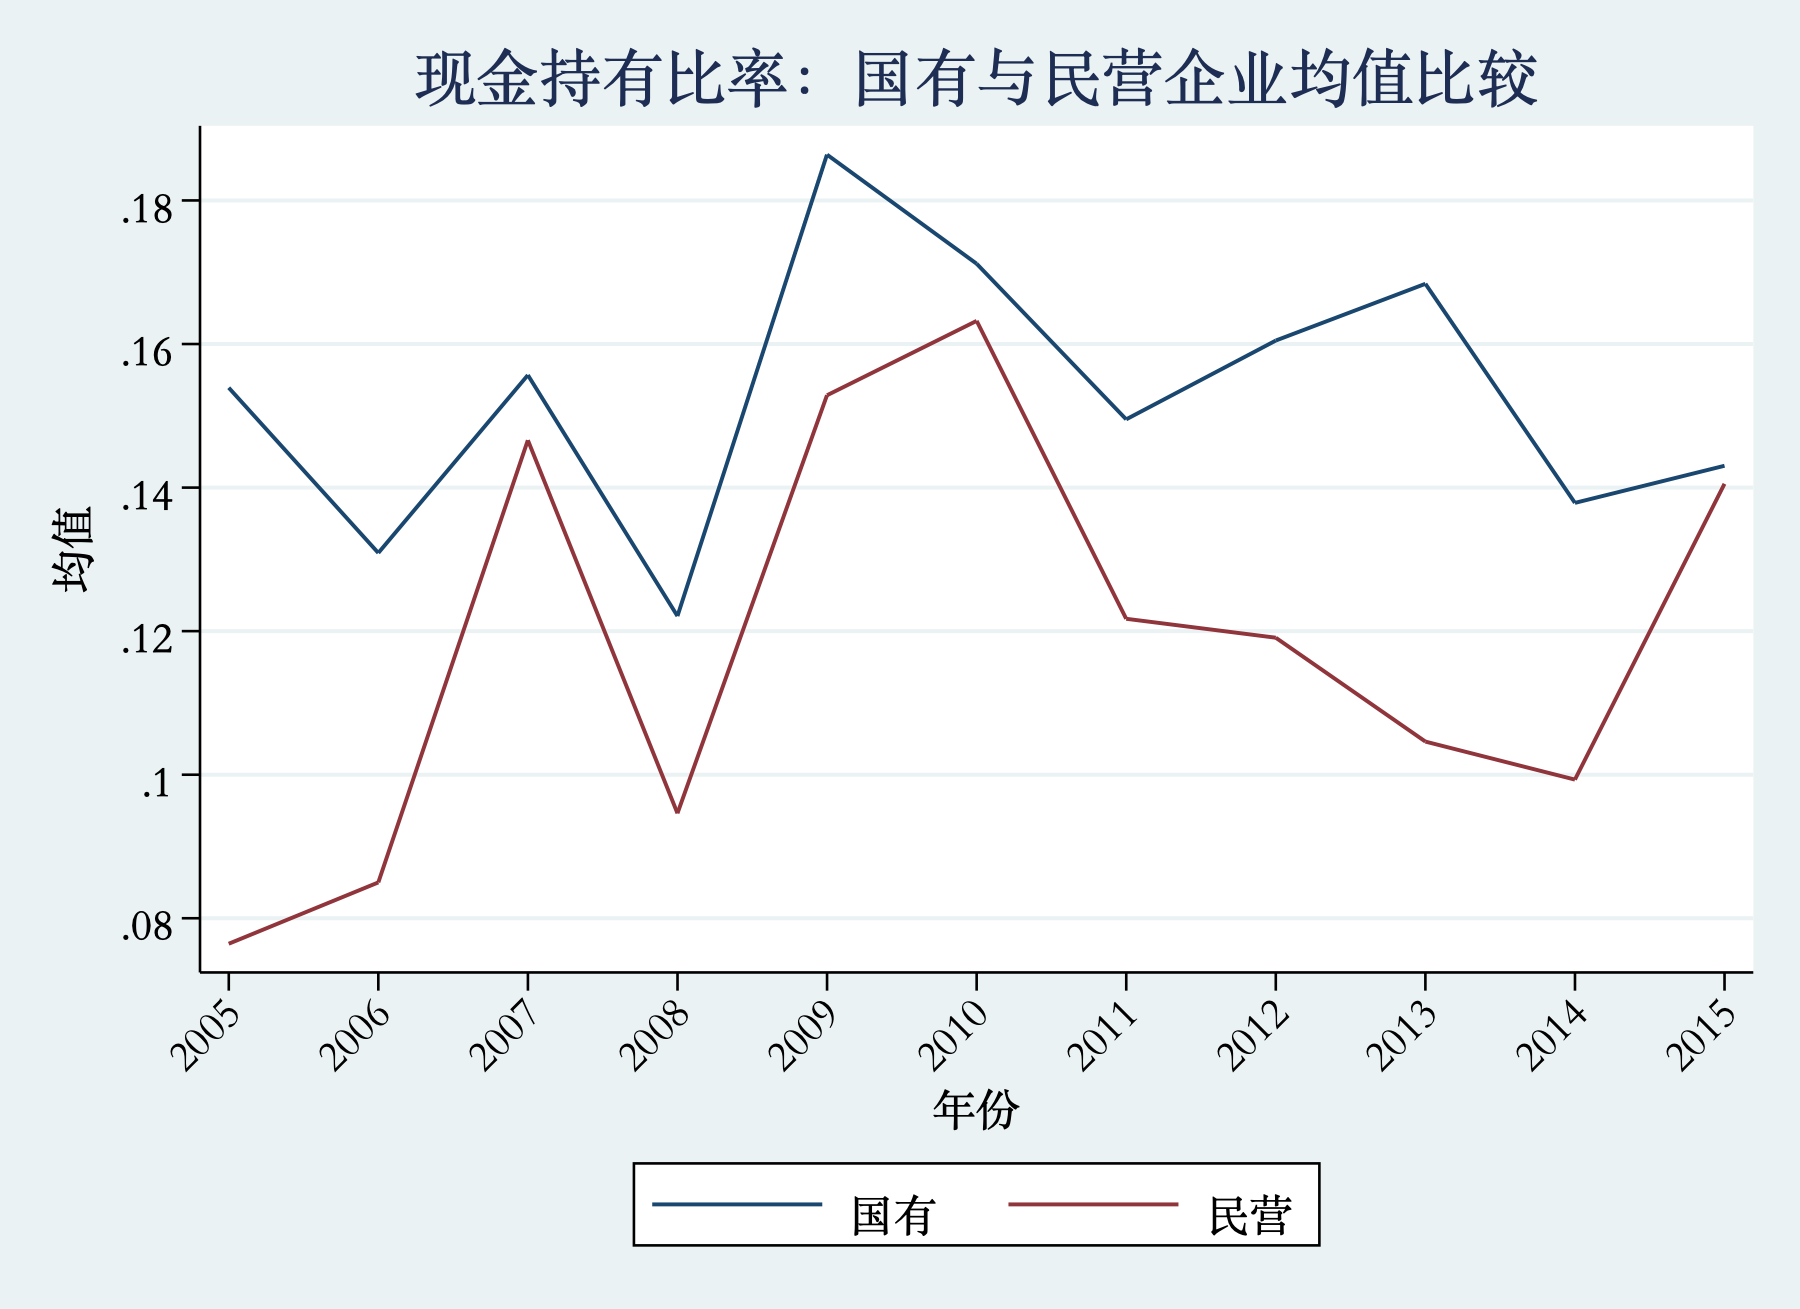

### 现金持有比率：国有与民营企业中位数比较

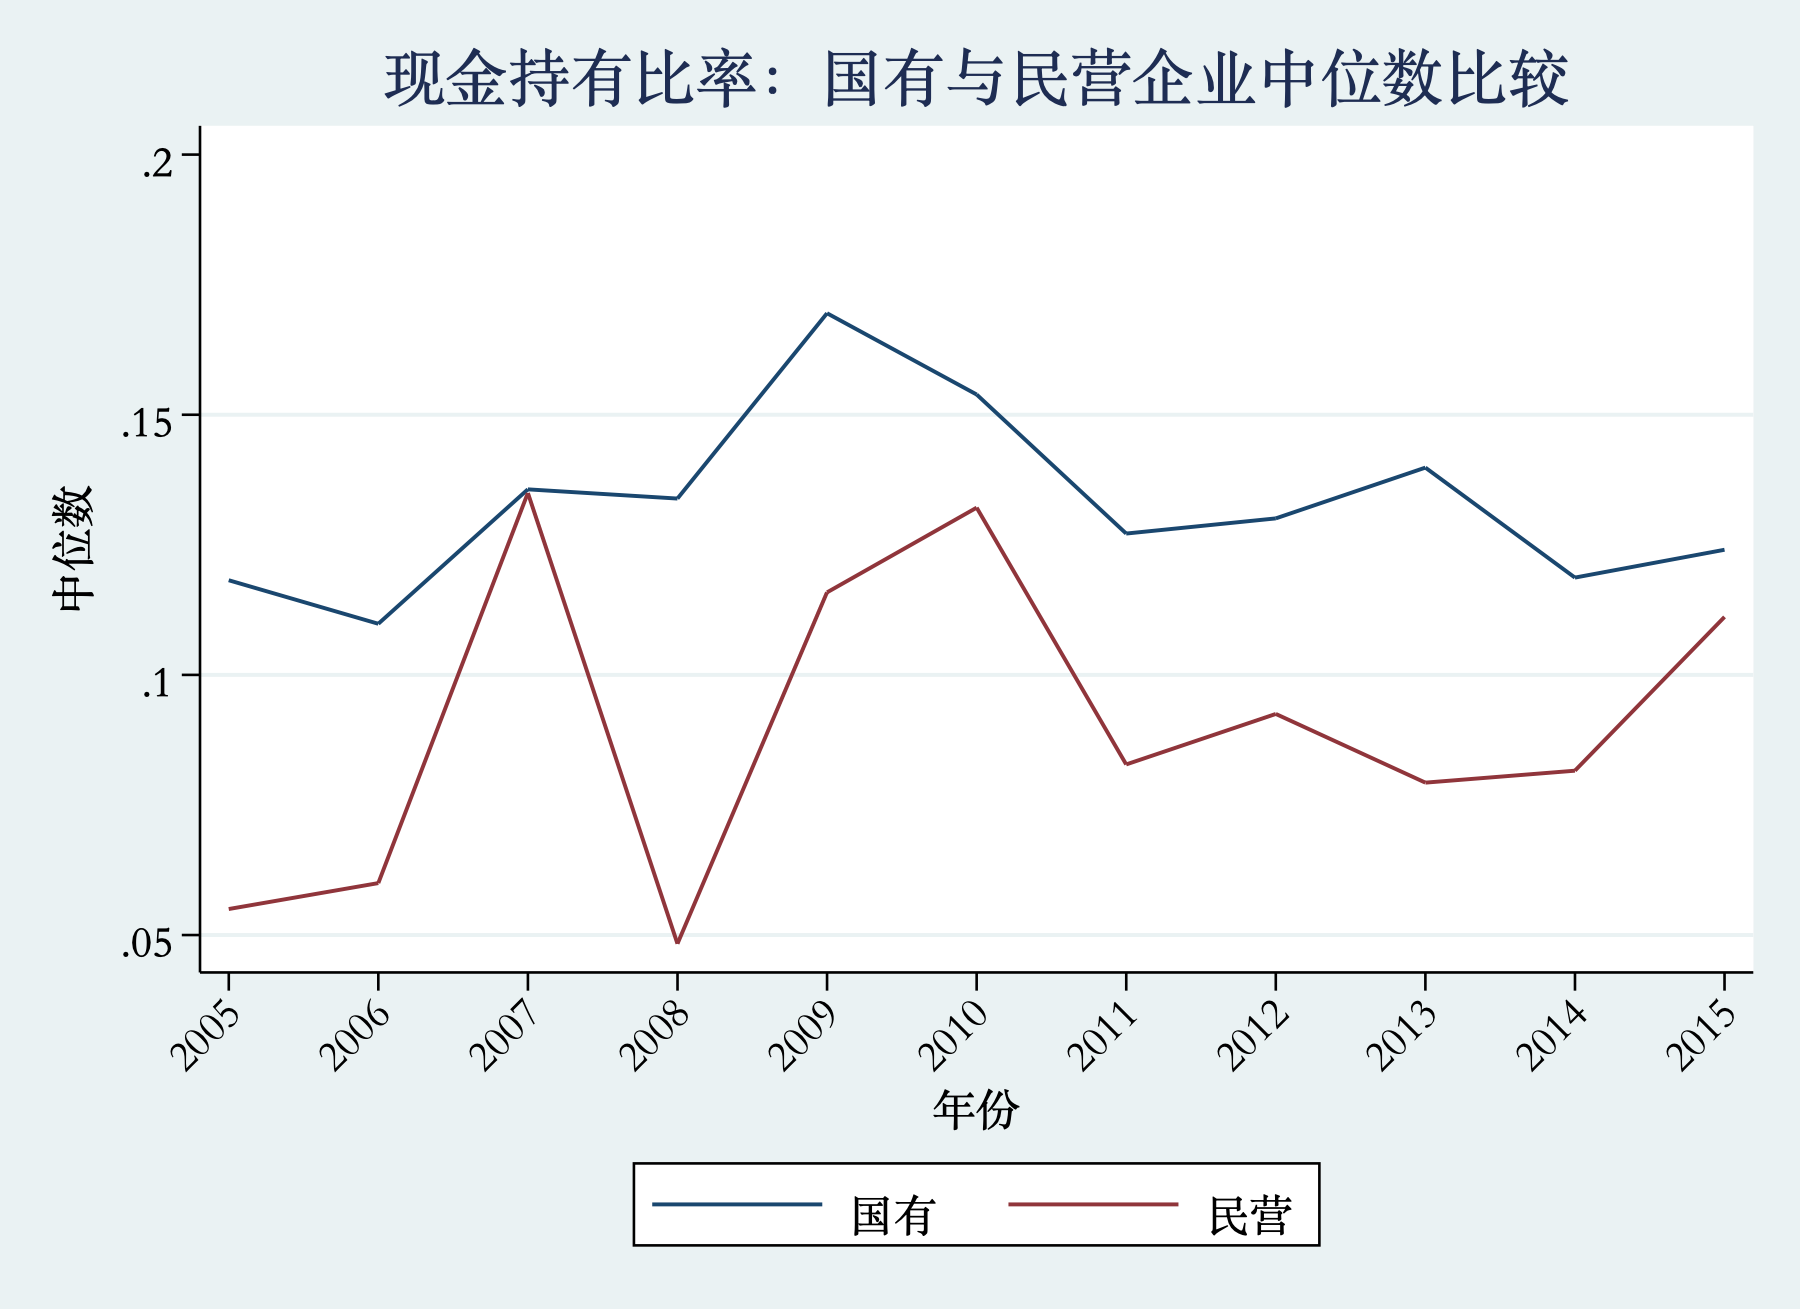

国有与民营企业全期指标对比如下：

| 指标 | 产权 | 有效样本量 | 全期均值（%） | 全期中位数（%） |
| --- | --- | --- | --- | --- |
| 资产负债率 | 国有 | 532 | 63.130 | 65.930 |
| 资产负债率 | 民营 | 370 | 76.260 | 60.290 |
| 银行贷款占比 | 国有 | 531 | 34.090 | 34.650 |
| 银行贷款占比 | 民营 | 370 | 30.180 | 26.980 |
| 短期负债占比 | 国有 | 532 | 73.490 | 73.190 |
| 短期负债占比 | 民营 | 370 | 77.850 | 80.930 |
| ROA | 国有 | 528 | 3.120 | 3.180 |
| ROA | 民营 | 365 | 3.150 | 2.400 |
| ROE | 国有 | 527 | 8.330 | 9.310 |
| ROE | 民营 | 356 | 7.600 | 6.390 |
| 现金持有比率 | 国有 | 532 | 15.360 | 13.140 |
| 现金持有比率 | 民营 | 370 | 12.190 | 9.480 |

### Step 3：结果解读

全期均值看，民营企业资产负债率均值约为 76.26%，高于国有企业的 63.13%；但中位数上，国有企业约为 65.93%，民营企业约为 60.29%。这说明民营企业均值较高很可能受到少数高杠杆或异常分母公司影响，不能只看均值作判断。短期负债占比方面，民营企业均值和中位数都高于国有企业，说明民营房地产公司在样本中更依赖短期负债，这一描述性差异较稳定。

银行贷款占比方面，国有企业全期均值约为 34.09%，民营企业约为 30.18%，国有企业略高。ROA 的国有和民营全期均值非常接近，分别约为 3.12% 和 3.15%；但 ROE 上国有企业均值和中位数略高。现金持有比率方面，国有企业全期均值约为 15.36%，高于民营企业的 12.19%。这些差异可能与企业规模、融资渠道、项目周期和样本构成有关，但本报告不做因果识别。

核心发现：

- 民营企业短期负债占比更高，这一差异在均值和中位数中都较明显。
- 银行贷款占比和现金持有比率上，国有企业整体略高。
- ROA 差异不大，ROE 的差异受异常权益分母影响，需要谨慎解释。
- 均值与中位数有时方向不同，说明离群值会影响产权组别比较。

## 5. 有效样本量、异常值和数据局限

### Step 1：Markdown 分析说明

本环节报告六个指标的年度有效样本量，并检查异常值。老师要求说明指标突变是否可能来自离群值、异常分母、样本进出或产权变更。因此，本报告不直接删除极端值，而是生成异常值检查表，作为后续解释依据。

检查规则：

- 资产负债率大于 2 标记为极端高杠杆。
- `abs(ROA) > 1` 标记为盈利能力极端值。
- `abs(ROE) > 1` 标记为权益分母或利润波动异常。
- 平均权益小于等于 0 的 ROE 在清洗阶段已置为缺失。

In [ ]:
* 六个指标年度有效样本量表
preserve
    collapse ///
        (count) N_lev = lev ///
        (count) N_bankloan = bankloan ///
        (count) N_shortdebt = shortdebt ///
        (count) N_roa = roa ///
        (count) N_roe = roe ///
        (count) N_cash_ta = cash_ta, by(year)
    export delimited using "`out'/六个指标年度有效样本量表.csv", replace
restore

* 异常值检查表
preserve
    gen flag_extreme = 0
    replace flag_extreme = 1 if lev > 2 & !missing(lev)
    replace flag_extreme = 1 if abs(roa) > 1 & !missing(roa)
    replace flag_extreme = 1 if abs(roe) > 1 & !missing(roe)
    keep if flag_extreme == 1
    keep stkcd shortname year owner_type listing_state ///
         lev bankloan shortdebt roa roe cash_ta ///
         total_assets total_liab total_equity avg_assets avg_equity net_profit
    export delimited using "`out'/异常值检查表.csv", replace
restore

六个指标年度有效样本量如下：

| 年份 | N_资产负债率 | N_银行贷款占比 | N_短期负债占比 | N_ROA | N_ROE | N_现金持有比率 |
| --- | --- | --- | --- | --- | --- | --- |
| 2005 | 55 | 55 | 55 | 55 | 53 | 55 |
| 2006 | 58 | 58 | 58 | 56 | 54 | 58 |
| 2007 | 65 | 65 | 65 | 62 | 60 | 65 |
| 2008 | 73 | 72 | 73 | 72 | 70 | 73 |
| 2009 | 81 | 81 | 81 | 80 | 78 | 81 |
| 2010 | 102 | 102 | 102 | 102 | 101 | 102 |
| 2011 | 105 | 105 | 105 | 105 | 104 | 105 |
| 2012 | 119 | 119 | 119 | 119 | 117 | 119 |
| 2013 | 113 | 113 | 113 | 113 | 113 | 113 |
| 2014 | 109 | 109 | 109 | 109 | 109 | 109 |
| 2015 | 109 | 109 | 109 | 107 | 106 | 109 |

主要异常值如下：

| 股票代码 | 简称 | 年份 | 产权 | 上市状态 | 资产负债率 | ROA | ROE |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 000007 | 深达声A | 2006 | 民营 | 正常上市 | 97.870 | -12.000 | -158.630 |
| 000007 | ST 达声A | 2007 | 民营 | ST | 101.130 | 1.130 | 197.950 |
| 000505 | 珠江控股 | 2014 | 国有 | 正常上市 | 98.840 | -12.540 | -245.890 |
| 000592 | *ST 昌源 | 2005 | 民营 | *ST | 272.320 | -41.110 |  |
| 000592 | S*ST 昌源 | 2006 | 民营 | 暂停上市 | 293.650 | 3.950 |  |
| 000592 | S*ST 昌源 | 2007 | 民营 | 暂停上市 | 181.070 | 169.650 |  |
| 000628 | 高新发展 | 2007 | 国有 | 正常上市 | 92.830 | -15.590 | -103.110 |
| 000979 | 中弘地产 | 2010 | 民营 | 正常上市 | 67.920 | 31.410 | 117.790 |
| 600603 | ST 兴业 | 2005 | 其他 | ST | 778.750 | 2.080 |  |
| 600603 | ST 兴业 | 2006 | 其他 | ST | 404.460 | 4.950 |  |
| 600603 | ST 兴业 | 2007 | 其他 | ST | 976.520 | 100.650 |  |
| 600603 | ST 兴业 | 2008 | 其他 | ST | 1814.100 | 125.930 |  |

### Step 3：结果解读

有效样本量显示，资产负债率、短期负债占比和现金持有比率每年观测较完整；银行贷款占比仅缺 1 个观测；ROA 和 ROE 缺失较多，主要来自上年资产/权益缺失或平均权益非正。2005 年 ROE 有效样本量为 53，低于当年公司数 55；2015 年 ROE 有效样本量为 106，低于公司数 109。这些缺失不是随机填零，而是按经济口径保留为缺失。

异常值主要集中在少数 ST 公司和负权益公司。`600603 ST 兴业` 在 2007—2010 年资产负债率极高，2009 年超过 55，原因是总资产很小而总负债较高；该公司平均权益为负，ROE 已置为缺失。`000592 S*ST 昌源` 和 `000007 ST 达声A` 也出现高杠杆或高 ROE，说明部分指标突变并不代表行业整体趋势，而可能来自异常分母、ST 状态或样本公司个体事件。

核心发现：

- 指标有效样本量总体充足，但 ROE 受权益分母限制更明显。
- 高杠杆和盈利能力极端值集中在少数 ST 或异常权益公司。
- 不缩尾可以保留真实风险信息，但报告解读必须区分典型趋势和离群值影响。
- 财务指标突变不能只按经济趋势解释，还要结合样本进出和异常分母。

## 6. 总体结论

本报告构建了 2005—2015 年房地产 A 股上市公司的年度非平衡面板，共 989 个公司—年度观测和 140 家公司。公司数量在 2005—2012 年明显增加，2012 年达到 119 家，之后回落至 2015 年的 109 家。产权结构上，国有企业始终占比较高，民营企业在 2008—2011 年占比相对较高，但整体仍低于国有企业。其他类别占比不为零，说明不能把非国有企业简单等同于民营企业。

财务特征方面，房地产企业资产负债率整体处于较高水平，但均值受少数极端公司影响较强；银行贷款占比和短期负债占比在样本期内整体下降，说明负债结构有所变化。盈利能力在 2007 年附近较高，2015 年 ROA 和 ROE 均明显走低。国有和民营企业存在若干描述性差异：民营企业短期负债占比更高，国有企业银行贷款占比和现金持有比率略高，ROA 差异不明显。由于没有进行因果识别，本文不把这些差异解释为产权导致的结果。

本分析也有局限。第一，行业和产权均按 CSMAR 年度分类识别，分类标准变化可能影响样本构成。第二，极端值没有缩尾处理，均值会受到少数 ST 公司、负权益和异常分母影响。第三，本报告只做描述性统计，不能回答产权变化是否导致财务指标变化。后续若要做因果分析，需要进一步控制公司固定效应、年份效应和其他财务特征。